Instalações e imports

In [1]:
import sys
print(sys.version)

3.12.0 (tags/v3.12.0:0fb18b0, Oct  2 2023, 13:03:39) [MSC v.1935 64 bit (AMD64)]


In [2]:
import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

import copy, csv, random, numpy as np
from math import sqrt
from tqdm import tqdm

import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from torch.utils.data import DataLoader, Subset

from mrfi import MRFI, EasyConfig
from mrfi.experiment import Acc_golden

# Configuração de reprodutibilidade
SEED = 0
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
try: torch.use_deterministic_algorithms(True)
except Exception: pass
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

Dispositivo: cpu


Configuração de  diretórios e dataset

In [3]:
import os
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Subset
import torch

# Define o diretório local para salvar os resultados
SAVE_DIR = './resultados_paper'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Resultados serão salvos em: {os.path.abspath(SAVE_DIR)}")

SUBSET_SIZE = 512
BATCH_SIZE = 32

normalize = transforms.Normalize((0.4914,0.4822,0.4465),(0.2023,0.1994,0.2010))
test_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(), 
    normalize
])

# O download=True vai baixar a pasta ./data direto no seu projeto local
test_ds = datasets.CIFAR10("./data", train=False, transform=test_tf, download=True)
all_indices = list(range(len(test_ds)))
import random
random.shuffle(all_indices)
subset_indices = all_indices[:min(SUBSET_SIZE, len(test_ds))]
test_subset = Subset(test_ds, subset_indices)
subset_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0) # num_workers=0 é mais seguro no Windows localmente

def cache_subset_to_device(loader, device):
    xs, ys = [], []
    for images, labels in loader:
        xs.append(images); ys.append(labels)
    return torch.cat(xs, dim=0).to(device), torch.cat(ys, dim=0).to(device)

cached_subset = cache_subset_to_device(subset_loader, device)
print(f"Subset Cacheado: X={cached_subset[0].shape}, Y={cached_subset[1].shape}")

Resultados serão salvos em: c:\Users\Herbert\Desktop\LSD\resultados_paper


c:\Users\Herbert\Desktop\LSD\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Subset Cacheado: X=torch.Size([512, 3, 224, 224]), Y=torch.Size([512])


Funções estatisticas adaptativas

In [4]:
Z_SCORES = {0.90: 1.645, 0.95: 1.96, 0.99: 2.5758, 0.999: 3.09}

def compute_n_with_fpc(N, e, p, confidence=0.99):
    if N <= 1: return min(N,1)
    t = Z_SCORES.get(confidence, 1.96)
    denom = 1.0 + (e**2 * (N - 1)) / (t**2 * max(p*(1-p), 1e-12))
    n = int(round(N / denom))
    return max(1, min(n, N))

def fpc_margin_of_error(p_hat, n, N, confidence=0.99):
    if n <= 0 or N <= 1: return 1.0
    t = Z_SCORES.get(confidence, 1.96)
    core = t * sqrt(max(p_hat*(1-p_hat), 0.0) / max(n,1))
    fpc = sqrt(max((N - n), 0) / max((N - 1), 1))
    return core * fpc

def calcular_e_goal_adaptativo(std_dev, e_min=0.01, e_max=0.05):
    """
    Se a variância (std_dev) do acc_drop for alta, exigimos e_goal rigoroso (0.01).
    Se for baixa/estável, podemos afrouxar o e_goal (0.05) para economizar tempo.
    """
    # Escala linear simples: assume-se que um std_dev > 0.05 é altamente instável
    fator = min(std_dev / 0.05, 1.0)
    # Interpolação invertida: alto fator -> baixo erro (mais rigor)
    e_goal = e_max - fator * (e_max - e_min)
    return max(e_min, min(e_max, e_goal))

@torch.no_grad()
def evaluate_model(model, X, Y, batch_size):
    model.eval(); getattr(model, 'observers_reset', lambda: None)()
    correct = 0
    for i in range(0, X.size(0), batch_size):
        pred = model(X[i:i+batch_size]).argmax(dim=1)
        correct += (pred == Y[i:i+batch_size]).sum().item()
    return correct, X.size(0)

Célula de finetunning

In [3]:
# -*- coding: utf-8 -*-
import csv
import os
import copy
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
from mrfi import MRFI, EasyConfig

# ==============================================================================
# IMPLEMENTAÇÃO DA ARQUITETURA (RESNET-32 PARA CIFAR-10)
# ==============================================================================
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion*planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion*planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion*planes)
            )
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class ResNet_CIFAR(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet_CIFAR, self).__init__()
        self.in_planes = 16
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.layer1 = self._make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 32, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 64, num_blocks[2], stride=2)
        self.linear = nn.Linear(64*block.expansion, num_classes)
    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for s in strides:
            layers.append(block(self.in_planes, planes, s))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = F.avg_pool2d(out, 8)
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out

# <--- DEFINIÇÃO DA RESNET-32 (5 blocos por camada) --->
def ResNet32(num_classes=10):
    return ResNet_CIFAR(BasicBlock, [5, 5, 5], num_classes=num_classes)

def evaluate_model(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

# ==============================================================================
# SETUP INICIAL DA ARQUITETURA (SEM PANDAS + COM MAPA DE BOMBARDEIO)
# ==============================================================================
print("\n--- INICIANDO RECUPERAÇÃO DOS DADOS ---")

device = torch.device("cpu") # Mude para 'cuda' se tiver GPU disponível
model_name = "resnet32"  # <--- ATUALIZADO PARA RESNET-32
SAVE_DIR = r"c:\Users\Herbert\Desktop\LSD\Experimento5\resultados_paper"
os.makedirs(SAVE_DIR, exist_ok=True)
csv_filename = "output.csv" 

camada_critica = ""
flips_por_camada = {}

# Lendo o arquivo usando apenas o módulo nativo 'csv' do Python
try:
    linhas = []
    with open(csv_filename, mode='r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            linhas.append({
                'layer': row['layer'],
                'param_index': int(row['param_index']),
                'vulnerability_pred': float(row['vulnerability_pred'])
            })
            
    # Ordena a lista inteira do maior pro menor (top 120 piores pesos)
    linhas_ordenadas = sorted(linhas, key=lambda x: x['vulnerability_pred'], reverse=True)
    top_120 = linhas_ordenadas[:120]
    
    camada_critica = top_120[0]['layer']
    
    for item in top_120:
        lname = item['layer']
        idx = item['param_index']
        flips_por_camada.setdefault(lname, []).append(idx)
        
    print(f"✅ Camada mapeada para o Teste de Fogo final: {camada_critica}")
    print(f"✅ Mapeados 120 pesos críticos para BOMBARDEIO ADVERSARIAL.")
except Exception as e:
    print(f"⚠️ Erro ao ler o CSV: {e}")
    raise SystemExit 

model = ResNet32(num_classes=10) # <--- INSTANCIANDO A RESNET-32
caminho_modelo_salvo = f"{model_name}_cifar10.pth" 
if os.path.exists(caminho_modelo_salvo):
    model.load_state_dict(torch.load(caminho_modelo_salvo, map_location=device))
    print(f"[*] Pesos do modelo original carregados.")
else:
    raise SystemExit(f"⚠️ Arquivo '{caminho_modelo_salvo}' não encontrado.")

model = model.to(device)

mrfi_cfg = r"""
faultinject:
  - type: weight
    enabled: True
    quantization:
      method: SymmericQuantization
      dynamic_range: auto
      bit_width: 8
    error_mode:
      method: IntFixedBitFlip
      bit_width: 8
      bit: 7
    selector:
      method: RandomPositionByNumber
      n: 0
    module_type: [Conv2d, Linear]
"""
fi_model = MRFI(copy.deepcopy(model).to(device), EasyConfig.load_string(mrfi_cfg))

layer_nodes = []
dict_modules_all = {}
for name, module in fi_model.named_modules():
    if isinstance(module, (nn.Conv2d, nn.Linear)) and getattr(module, 'weight', None) is not None:
        dict_modules_all[name] = module
        if getattr(module, 'FI_config', None) and module.FI_config.weights:
            layer_nodes.append({
                "name": name, "module": module, "cfg": module.FI_config.weights[0],
                "n_params": module.weight.numel(), "bit_w": 8
            })

fi_model.get_weights_configs().enabled = False

# ------------------------------------------------------------------------------
# PREPARAÇÃO DE DADOS (CIFAR-10)
# ------------------------------------------------------------------------------
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4), 
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)),
])
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
dataloader_train = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0) 

transform_test = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)), 
])
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# ==============================================================================
# FASE 4: O TREINAMENTO DEFINITIVO (QAT + 120 BITFLIPS + BIMODAL FORÇADA)
# ==============================================================================
print("\n--- INICIANDO FASE 4: ADVERSARIAL QAT + BIMODAL (PILARES ±0.20) ---")

# Desliga o MRFI temporariamente para não travar o otimizador
fi_model.get_weights_configs().enabled = False

# 1. CRIA O DICIONÁRIO APONTANDO PARA O MODELO REAL (E não para o clone)
dict_modules_model = {}
for name, module in model.named_modules():
    if isinstance(module, (nn.Conv2d, nn.Linear)) and getattr(module, 'weight', None) is not None:
        dict_modules_model[name] = module

# PARÂMETROS DA REDE BIMODAL RESPIRÁVEL
ALPHA = 0.2        
LAMBDA_DW = 200.0   
CLIPPING_MAX = 0.1

# O Otimizador agora controla o modelo real
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=0.0)
criterion = nn.CrossEntropyLoss()

MAX_EPOCHS = 20  
ALVO_ACURACIA = 0.90 

for epoch in range(MAX_EPOCHS):
    model.train() 
    running_loss = 0.0
    running_loss_dw = 0.0
    
    for inputs, labels in tqdm(dataloader_train, desc=f"Época {epoch+1}/{MAX_EPOCHS}"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        
        # 1. CÁLCULO DA BIMODALIDADE (Feito nos pesos puros FP32)
        loss_double_well = 0.0
        for mod in dict_modules_model.values():
            w = mod.weight
            loss_double_well += torch.mean((w**2 - ALPHA**2)**2)
            
        # 2. SALVA OS PESOS REAIS (FP32) ANTES DE DESTRUÍ-LOS
        pesos_fp32 = {name: mod.weight.data.clone() for name, mod in dict_modules_model.items()}
        
        # 3. O ATAQUE: QAT E BOMBARDEIO NOS 120 ALVOS
        ataque_ativo = random.random() < 0.10
        with torch.no_grad():
            for name, mod in dict_modules_model.items():
                w = mod.weight.data
                w_max = w.abs().max().item()
                scale = w_max / 127.0 if w_max > 0 else 1.0
                
                # QAT Global
                w_qat = torch.round(w / scale).clamp(-128, 127) * scale
                
                # Bombardeio nos 120 alvos cruciais
                if ataque_ativo and name in flips_por_camada:
                    w_flat = w_qat.view(-1)
                    for idx in flips_por_camada[name]:
                        val = w_flat[idx].item()
                        q_val = int(round(val / scale))
                        q_val = max(-128, min(127, q_val))
                        u_val = q_val & 0xFF
                        u_val ^= (1 << 7) # MSB Flip
                        q_flip = u_val if u_val < 128 else u_val - 256
                        w_flat[idx] = q_flip * scale
                    w_qat = w_flat.view(w_qat.shape)
                
                # Aplica a sujeira sem quebrar o grafo do PyTorch
                mod.weight.data.copy_(w_qat)
        
        # 4. FORWARD PASS SOB ATAQUE E QUANTIZAÇÃO (Usando o model puro)
        outputs = model(inputs)
        loss_classificacao = criterion(outputs, labels)
        
        # 5. BACKPROPAGATION COM AS DUAS FORÇAS
        loss_total = loss_classificacao + (LAMBDA_DW * loss_double_well)
        loss_total.backward()
        
        # 6. RESTAURA OS PESOS FP32 PARA O OTIMIZADOR ATUALIZAR
        with torch.no_grad():
            for name, mod in dict_modules_model.items():
                mod.weight.data.copy_(pesos_fp32[name])
                
        # 7. PASSO DO OTIMIZADOR
        optimizer.step()
        
        # 8. REDE DE SEGURANÇA (CLIPPING)
        with torch.no_grad():
            for mod in dict_modules_model.values():
                mod.weight.clamp_(-CLIPPING_MAX, CLIPPING_MAX)
            
        running_loss += loss_classificacao.item()
        running_loss_dw += loss_double_well.item()

    # AVALIAÇÃO DA ÉPOCA (Avaliando o modelo real que foi treinado!)
    acc_val = evaluate_model(model, test_loader, device)

    print(f"[*] Época {epoch+1} | Loss Classe: {running_loss/len(dataloader_train):.4f} | Loss Bimodal: {running_loss_dw/len(dataloader_train):.6f} | Acc INT8: {acc_val*100:.2f}%")

    if acc_val >= ALVO_ACURACIA:
        print(f"\n🎯 EARLY STOPPING ATIVADO! A rede estabilizou sob QAT + Flips + Bimodal.")
        break

# Sincroniza a inteligência adquirida de volta para a carcaça do MRFI
fi_model.model.load_state_dict(model.state_dict())

# ==============================================================================
# FASE 5: TESTE DE IMUNIDADE E EXPORTAÇÃO
# ==============================================================================
print("\n--- INICIANDO FASE 5: TESTE DE FOGO (10K IMAGENS) E SALVAMENTO ---")

# Teste Golden (Com MRFI ativado, mas 0 flips)
fi_model.get_weights_configs().enabled = True
for n in layer_nodes:
    n["cfg"].selector.args.__dict__.setdefault("raw_dict", {})["n"] = 0 
acc_clean = evaluate_model(fi_model.model, test_loader, device)
print(f"=> Acurácia Golden Pós-Vacina Bimodal (0 Flips): {acc_clean*100:.2f}%")

# Salvamento
caminho_modelo_vacinado = os.path.join(SAVE_DIR, f"{model_name}_cifar10_vacinado.pth")
torch.save(fi_model.model.state_dict(), caminho_modelo_vacinado)
print(f"💾 CÉREBRO ADVERSARIAL (BIMODAL) SALVO EM: {caminho_modelo_vacinado}")

# O Teste de Estresse Máximo na Pior Camada
node_cfg = next(n["cfg"] for n in layer_nodes if n["name"] == camada_critica)
node_cfg.enabled = True
node_cfg.selector.args.__dict__["raw_dict"]["n"] = 6

print(f"=> Rodando avaliação sob ataque severo (6 flips na {camada_critica})...")
acc_vacinada_perc = evaluate_model(fi_model.model, test_loader, device) * 100

print(f"=> Acurácia sob Ataque de Estresse Fixo: {acc_vacinada_perc:.2f}%")

node_cfg.enabled = False
print("\n🚀 TREINAMENTO DE IMUNIDADE CONCLUÍDO COM SUCESSO!")


--- INICIANDO RECUPERAÇÃO DOS DADOS ---
✅ Camada mapeada para o Teste de Fogo final: conv1
✅ Mapeados 120 pesos críticos para BOMBARDEIO ADVERSARIAL.
[*] Pesos do modelo original carregados.

--- INICIANDO FASE 4: ADVERSARIAL QAT + BIMODAL (PILARES ±0.20) ---


Época 1/20: 100%|██████████| 391/391 [03:09<00:00,  2.06it/s]


[*] Época 1 | Loss Classe: 0.5644 | Loss Bimodal: 0.049145 | Acc INT8: 91.46%

🎯 EARLY STOPPING ATIVADO! A rede estabilizou sob QAT + Flips + Bimodal.

--- INICIANDO FASE 5: TESTE DE FOGO (10K IMAGENS) E SALVAMENTO ---
=> Acurácia Golden Pós-Vacina Bimodal (0 Flips): 91.45%
💾 CÉREBRO ADVERSARIAL (BIMODAL) SALVO EM: c:\Users\Herbert\Desktop\LSD\Experimento5\resultados_paper\resnet32_cifar10_vacinado.pth
=> Rodando avaliação sob ataque severo (6 flips na conv1)...
=> Acurácia sob Ataque de Estresse Fixo: 91.24%

🚀 TREINAMENTO DE IMUNIDADE CONCLUÍDO COM SUCESSO!


Teste progressivo aleatório


   INICIANDO TESTE DE ESTRESSE GLOBAL (CURVA DE COLAPSO)
[*] Cacheando Subset de Teste na RAM...


c:\Users\Herbert\Desktop\LSD\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")



--- Testando: Modelo Original ---
 ->   0 Flips Globais Aleatórios | Acurácia: 93.55%
 ->   1 Flips Globais Aleatórios | Acurácia: 92.38%
 ->   6 Flips Globais Aleatórios | Acurácia: 56.05%
 ->  15 Flips Globais Aleatórios | Acurácia: 26.95%
 ->  30 Flips Globais Aleatórios | Acurácia: 13.87%
 ->  60 Flips Globais Aleatórios | Acurácia: 13.48%
 -> 100 Flips Globais Aleatórios | Acurácia: 10.35%

--- Testando: Modelo Vacinado ---
 ->   0 Flips Globais Aleatórios | Acurácia: 91.21%
 ->   1 Flips Globais Aleatórios | Acurácia: 91.02%
 ->   6 Flips Globais Aleatórios | Acurácia: 88.67%
 ->  15 Flips Globais Aleatórios | Acurácia: 90.62%
 ->  30 Flips Globais Aleatórios | Acurácia: 77.73%
 ->  60 Flips Globais Aleatórios | Acurácia: 77.93%
 -> 100 Flips Globais Aleatórios | Acurácia: 48.83%

✅ Resultados numéricos salvos em: c:\Users\Herbert\Desktop\LSD\Experimento5\resultados_paper\resultado_stress_comparativo_global_resnet32.csv
[*] Gerando Gráfico da Curva de Colapso Global...


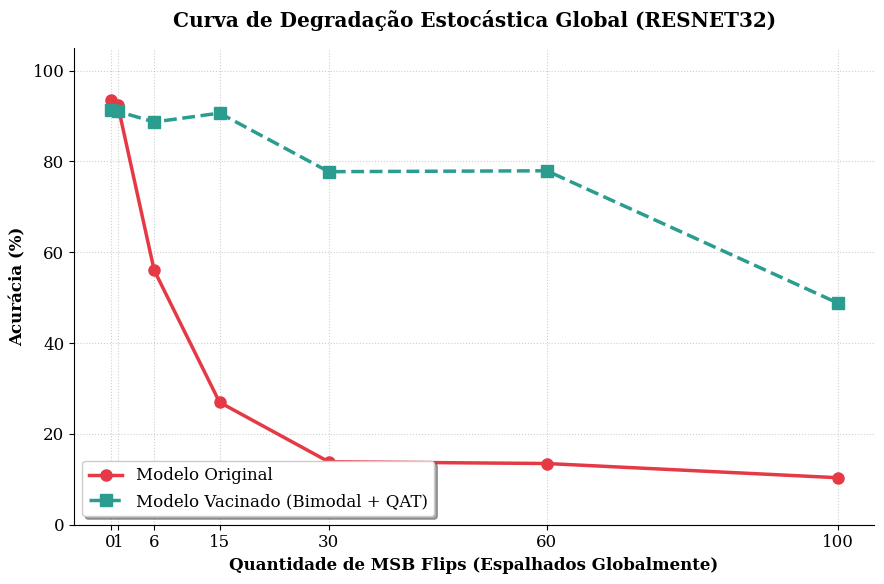

🚀 Gráfico de stress salvo em: c:\Users\Herbert\Desktop\LSD\Experimento5\resultados_paper\grafico_stress_progressivo_global_resnet32.png


In [2]:
# -*- coding: utf-8 -*-
# === ATAQUE ESTOCÁSTICO GLOBAL (CURVA DE COLAPSO) ===

import csv
import os
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from mrfi import MRFI, EasyConfig

print("\n==================================================================")
print("   INICIANDO TESTE DE ESTRESSE GLOBAL (CURVA DE COLAPSO)")
print("==================================================================")

# ==============================================================================
# IMPLEMENTAÇÃO DA RESNET-32
# ==============================================================================
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion*planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion*planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion*planes)
            )
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class ResNet_CIFAR(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet_CIFAR, self).__init__()
        self.in_planes = 16
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.layer1 = self._make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 32, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 64, num_blocks[2], stride=2)
        self.linear = nn.Linear(64*block.expansion, num_classes)
    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for s in strides:
            layers.append(block(self.in_planes, planes, s))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = F.avg_pool2d(out, 8)
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out

# Atualizado para instanciar a ResNet-32 (5 blocos residuais por camada)
def ResNet32(num_classes=10):
    return ResNet_CIFAR(BasicBlock, [5, 5, 5], num_classes=num_classes)

# ==============================================================================
# CONFIGURAÇÕES E DADOS
# ==============================================================================
device = torch.device("cpu") # Mude para 'cuda' se tiver GPU disponível
model_name = "resnet32"
SAVE_DIR = r"c:\Users\Herbert\Desktop\LSD\Experimento5\resultados_paper"

print("[*] Cacheando Subset de Teste na RAM...")
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)),
])

test_dataset = datasets.CIFAR10(root='./data', train=False, download=False, transform=transform_test)
subset_loader = DataLoader(Subset(test_dataset, range(512)), batch_size=128, shuffle=False)

all_x, all_y = [], []
for x, y in subset_loader:
    all_x.append(x)
    all_y.append(y)
cached_subset = (torch.cat(all_x).to(device), torch.cat(all_y).to(device))
SUBSET_SIZE = 512

# ==============================================================================
# FUNÇÃO DE TESTE DE ESTRESSE GLOBAL
# ==============================================================================
def executar_teste_estresse_global(caminho_modelo, nome_label):
    print(f"\n--- Testando: {nome_label} ---")
    
    # Garantindo que a ResNet32 seja chamada
    model = ResNet32(num_classes=10)
    model.load_state_dict(torch.load(caminho_modelo, map_location=device))
    model.eval().to(device)

    # Configuração do MRFI para atacar globalmente (module_type: [Conv2d, Linear])
    mrfi_cfg = r"""
    faultinject:
      - type: weight
        enabled: False
        quantization: {method: SymmericQuantization, dynamic_range: auto, bit_width: 8}
        error_mode: {method: IntFixedBitFlip, bit_width: 8, bit: 7}
        selector: {method: RandomPositionByNumber, n: 1}
        module_type: [Conv2d, Linear]
    """
    fi_model = MRFI(model, EasyConfig.load_string(mrfi_cfg))

    n_injections_list = [0, 1, 6, 15, 30, 60, 100]
    resultados = []

    for n_flips in n_injections_list:
        if n_flips == 0:
            # Desabilita injeções para baseline
            for name, module in fi_model.named_modules():
                if hasattr(module, 'FI_config') and module.FI_config.weights:
                    module.FI_config.weights[0].enabled = False
        else:
            # Habilita as injeções globalmente (O MRFI espalha o 'n' entre os módulos configurados)
            for name, module in fi_model.named_modules():
                if hasattr(module, 'FI_config') and module.FI_config.weights:
                    cfg = module.FI_config.weights[0]
                    cfg.enabled = True
                    cfg.selector.method = "RandomPositionByNumber"
                    cfg.selector.args.__dict__.setdefault("raw_dict", {}).clear()
                    cfg.selector.args.__dict__["raw_dict"]["n"] = n_flips
                    em_raw = cfg.error_mode.args.__dict__.setdefault("raw_dict", {})
                    em_raw.clear()
                    em_raw["bit_width"] = 8
                    em_raw["bit"] = 7 

        with torch.no_grad():
            outputs = fi_model(cached_subset[0])
            _, predi = torch.max(outputs, 1)
            acc = (predi == cached_subset[1]).sum().item()
        
        acc_perc = (acc / SUBSET_SIZE) * 100
        resultados.append((n_flips, acc_perc))
        print(f" -> {n_flips:3d} Flips Globais Aleatórios | Acurácia: {acc_perc:5.2f}%")

    return resultados

# ==============================================================================
# EXECUÇÃO E COMPARAÇÃO
# ==============================================================================
caminho_orig = f"{model_name}_cifar10.pth"
caminho_vac = os.path.join(SAVE_DIR, f"{model_name}_cifar10_vacinado.pth")

res_original = executar_teste_estresse_global(caminho_orig, "Modelo Original")
res_vacinado = executar_teste_estresse_global(caminho_vac, "Modelo Vacinado")

# Salvando no CSV Conjunto
csv_stress_filename = os.path.join(SAVE_DIR, f"resultado_stress_comparativo_global_{model_name}.csv")
try:
    with open(csv_stress_filename, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["Flips_Injetados_Global", "Acuracia_Original_Perc", "Acuracia_Vacinada_Perc"])
        for (n_flips, acc_orig), (_, acc_vac) in zip(res_original, res_vacinado):
            writer.writerow([n_flips, round(acc_orig, 2), round(acc_vac, 2)])
    print(f"\n✅ Resultados numéricos salvos em: {csv_stress_filename}")
except Exception as e:
    print(f"⚠️ Erro ao salvar CSV: {e}")

# ==============================================================================
# PLOTAGEM DA CURVA DE COLAPSO
# ==============================================================================
print("[*] Gerando Gráfico da Curva de Colapso Global...")
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})
fig, ax = plt.subplots(figsize=(9, 6))

eixo_x = [r[0] for r in res_original]
curva_orig = [r[1] for r in res_original]
curva_vac = [r[1] for r in res_vacinado]

ax.plot(eixo_x, curva_orig, marker='o', linestyle='-', color='#E63946', linewidth=2.5, markersize=8, label='Modelo Original')
# Legenda atualizada para refletir a Bimodalidade
ax.plot(eixo_x, curva_vac, marker='s', linestyle='--', color='#2A9D8F', linewidth=2.5, markersize=8, label='Modelo Vacinado (Bimodal + QAT)')

ax.set_xlabel('Quantidade de MSB Flips (Espalhados Globalmente)', fontweight='bold')
ax.set_ylabel('Acurácia (%)', fontweight='bold')
ax.set_title(f'Curva de Degradação Estocástica Global ({model_name.upper()})', fontweight='bold', pad=15)

ax.set_ylim(0, 105)
ax.set_xticks(eixo_x)
ax.grid(axis='both', linestyle=':', alpha=0.6)
ax.legend(loc='lower left', frameon=True, shadow=True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
grafico_png = os.path.join(SAVE_DIR, f"grafico_stress_progressivo_global_{model_name}.png")
plt.savefig(grafico_png, dpi=300, bbox_inches='tight')
plt.show()

print(f"🚀 Gráfico de stress salvo em: {grafico_png}")

busca genética


   INICIANDO ATAQUE ADAPTATIVO GENÉTICO GLOBAL (RESNET-32 | EXACT MODE)

[*] Lendo o arquivo output.csv e definindo o Pool de Candidatos Globais...
  -> Camada com maior pico absoluto: conv1 (Apenas para referência)
  -> 120 parâmetros carregados do Pool Evolutivo Global (espalhados em 2 camadas).

[*] Carregando Datasets na Memória...


c:\Users\Herbert\Desktop\LSD\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")



--- INICIANDO CAÇADA EVOLUTIVA PARA: MODELO ORIGINAL ---
[*] Acurácia Golden Inicial (MODELO ORIGINAL): 93.55%
  -> Gen 1: Novo pior ataque! Acurácia caiu para: 53.32% (usando 6 flips)
  -> Gen 2: Novo pior ataque! Acurácia caiu para: 24.02% (usando 5 flips)
  -> Gen 3: Novo pior ataque! Acurácia caiu para: 23.44% (usando 6 flips)
  -> Gen 5: Novo pior ataque! Acurácia caiu para: 19.73% (usando 6 flips)
  -> Gen 7: Novo pior ataque! Acurácia caiu para: 19.53% (usando 6 flips)
  -> Gen 8: Novo pior ataque! Acurácia caiu para: 11.52% (usando 6 flips)
  -> TARGET DE DESTRUIÇÃO ATINGIDO!
[*] Tempo do AG: 156.07s
  [*] Poda (Pruning) ativada. Limpando flips desnecessários...
  -> PRUNE EFICAZ: Flips reduzidos de 6 para 5!
  💾 Planilha de ataques exatos salva em: c:\Users\Herbert\Desktop\LSD\Experimento5\resultados_paper\flips_MODELO_ORIGINAL_resnet32.csv
✅ Caçada Finalizada! Acurácia Final (MODELO ORIGINAL): 18.36%


--- INICIANDO CAÇADA EVOLUTIVA PARA: MODELO VACINADO (Bimodal + QAT) ---


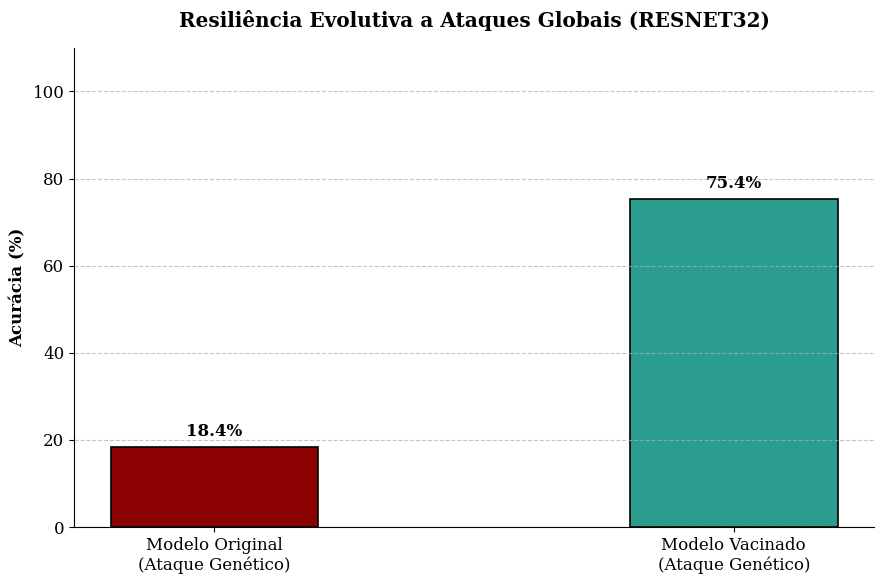


🚀 EXPERIMENTO GENÉTICO CONCLUÍDO! Gráfico salvo em: c:\Users\Herbert\Desktop\LSD\Experimento5\resultados_paper\grafico_ag_prune_resnet32.png


In [ ]:
# -*- coding: utf-8 -*-
# === ATAQUE ADAPTATIVO WHITE-BOX COM AG + PRUNE (EXACT MODE GLOBAL) ===

import os
import random
import copy
import time
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
from mrfi import MRFI, EasyConfig

print("\n==================================================================")
print("   INICIANDO ATAQUE ADAPTATIVO GENÉTICO GLOBAL (RESNET-32 | EXACT MODE)")
print("==================================================================")

# ==============================================================================
# IMPLEMENTAÇÃO DA RESNET PARA CIFAR-10 (32x32)
# ==============================================================================
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion*planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion*planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion*planes)
            )
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class ResNet_CIFAR(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet_CIFAR, self).__init__()
        self.in_planes = 16
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.layer1 = self._make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 32, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 64, num_blocks[2], stride=2)
        self.linear = nn.Linear(64*block.expansion, num_classes)
    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for s in strides:
            layers.append(block(self.in_planes, planes, s))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = F.avg_pool2d(out, 8)
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out

# Nova função para ResNet-32 [5, 5, 5]
def ResNet32(num_classes=10):
    return ResNet_CIFAR(BasicBlock, [5, 5, 5], num_classes=num_classes)

# ==============================================================================
# CONFIGURAÇÕES GERAIS
# ==============================================================================
device = torch.device("cpu") # Mude para 'cuda' se tiver GPU disponível
model_name = "resnet32"  
SAVE_DIR = r"c:\Users\Herbert\Desktop\LSD\Experimento5\resultados_paper"
os.makedirs(SAVE_DIR, exist_ok=True)

caminho_modelo_limpo = f"{model_name}_cifar10.pth"
caminho_modelo_vacinado = os.path.join(SAVE_DIR, f"{model_name}_cifar10_vacinado.pth")
csv_filename = "output.csv" 

# Parâmetros do AG 
BATCH_SIZE_GPU = 128
N_INITIAL_CANDIDATES = 120 
GA_NUM_GENERATIONS = 20   
GA_POPULATION_SIZE = 40
GA_NUM_ELITES = 4
GA_MUTATION_RATE = 0.025
GA_TOURNAMENT_SIZE = 3
GA_INITIAL_FLIP_PROB = 0.05
GA_MAX_FLIPS = 6
GA_TARGET_ACCURACY = 0.15 
BIT_TO_FLIP = 7 
GA_ENABLE_POST_PRUNING = False
GA_PRUNE_ORDER = "low_vuln_first"

# ==============================================================================
# PREPARAÇÃO DE DADOS (CACHE) & LEITURA DO CSV GLOBAL
# ==============================================================================
print(f"\n[*] Lendo o arquivo {csv_filename} e definindo o Pool de Candidatos Globais...")
try:
    df = pd.read_csv(csv_filename)
    camada_critica = df.loc[df['vulnerability_pred'].idxmax(), 'layer']
    print(f"  -> Camada com maior pico absoluto: {camada_critica} (Apenas para referência)")
    
    # Extraindo os 120 piores da rede INTEIRA, sem filtrar por camada
    df_candidatos = df.nlargest(N_INITIAL_CANDIDATES, 'vulnerability_pred')
    candidate_pool_global = df_candidatos.to_dict('records')
    
    # Verificando quantas camadas diferentes estão no pool
    camadas_afetadas = df_candidatos['layer'].nunique()
    print(f"  -> {len(candidate_pool_global)} parâmetros carregados do Pool Evolutivo Global (espalhados em {camadas_afetadas} camadas).")
except Exception as e:
    print(f"⚠️ Erro fatal ao ler {csv_filename}. Erro: {e}")
    raise SystemExit

print("\n[*] Carregando Datasets na Memória...")
normalize = transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
test_tf = transforms.Compose([transforms.ToTensor(), normalize])
test_ds = datasets.CIFAR10("./data", train=False, transform=test_tf, download=False)

# Carregando apenas o subset exato (512)
full_loader = DataLoader(Subset(test_ds, range(512)), batch_size=BATCH_SIZE_GPU, shuffle=False)

def cache_loader_to_device(loader, device):
    xs, ys = [], []
    for x, y in loader:
        xs.append(x); ys.append(y)
    return torch.cat(xs, dim=0).to(device), torch.cat(ys, dim=0).to(device)

cached_full = cache_loader_to_device(full_loader, device)

# ==============================================================================
# FUNÇÕES DE OTIMIZAÇÃO DO INJETOR
# ==============================================================================
def eval_acc_fast(fi_model, cached_data, batch_size=BATCH_SIZE_GPU):
    fi_model.eval()
    X, Y = cached_data
    total = Y.size(0)
    correct = 0
    with torch.no_grad():
        for i in range(0, total, batch_size):
            xb, yb = X[i:i+batch_size], Y[i:i+batch_size]
            pred = fi_model(xb).argmax(dim=1)
            correct += (pred == yb).sum().item()
    return correct / max(total, 1)

def collect_weight_fi_layers(fi_model: MRFI) -> dict:
    layer_nodes = {}
    for name, module in fi_model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)) and getattr(module, "FI_config", None) and module.FI_config.weights:
            cfg = module.FI_config.weights[0]
            layer_nodes[name] = {
                "name": name, "module": module, "cfg": cfg, "n_params": module.weight.numel(),
                "sel_args": cfg.selector.args.__dict__.setdefault("raw_dict", {}),
                "err_args": cfg.error_mode.args.__dict__.setdefault("raw_dict", {})
            }
    return layer_nodes

def apply_active_flips_fast(layer_nodes: dict, flips_info_list: list):
    flips_by_layer = {}
    for f in flips_info_list:
        flips_by_layer.setdefault(f["layer"], []).append(int(f["param_index"]))

    for layer_name, node in layer_nodes.items():
        cfg = node["cfg"]
        target_positions = flips_by_layer.get(layer_name, [])
        if not target_positions:
            cfg.enabled = False
        else:
            cfg.enabled = True
            cfg.selector.method = "FixPositions"
            node["sel_args"].clear()
            node["sel_args"]["positions"] = target_positions
            cfg.error_mode.method = "IntFixedBitFlip"
            node["err_args"].clear()
            node["err_args"]["bit_width"] = 8
            node["err_args"]["bit"] = [BIT_TO_FLIP] * len(target_positions)

def freeze_dynamic_ranges(layer_nodes: dict):
    for node in layer_nodes.values():
        module, cfg = node["module"], node["cfg"]
        q_args = cfg.quantization.args.__dict__.get("raw_dict", {})
        if q_args.get("dynamic_range") == "auto":
            with torch.no_grad():
                q_args["dynamic_range"] = float(module.weight.abs().max().item())

# ==============================================================================
# MOTORES DO ALGORITMO GENÉTICO E PRUNE
# ==============================================================================
def create_initial_population(pop_size, chrom_length, flip_prob, max_flips):
    population = []
    for _ in range(pop_size):
        chrom = np.random.choice([0, 1], size=(chrom_length,), p=[1-flip_prob, flip_prob])
        while np.sum(chrom) > max_flips:
            ones = np.where(chrom == 1)[0]
            if len(ones) > 0: chrom[np.random.choice(ones)] = 0
            else: break
        population.append(chrom.astype(np.int8))
    return population

def translate_chromosome_to_flips(chromosome, candidate_pool):
    return [candidate_pool[i] for i in np.where(chromosome == 1)[0]]

def evaluate_fitness_fast(chromosome, candidate_pool, layer_nodes, fi_model, cached_data, baseline_acc):
    flips = translate_chromosome_to_flips(chromosome, candidate_pool)
    if not flips: return 0.0, baseline_acc
    apply_active_flips_fast(layer_nodes, flips)
    acc_i = eval_acc_fast(fi_model, cached_data)
    return baseline_acc - acc_i, acc_i

def selection(pop_with_fitness, tour_size):
    contenders = random.sample(pop_with_fitness, min(tour_size, len(pop_with_fitness)))
    contenders.sort(key=lambda x: x[0], reverse=True)
    return contenders[0][2]

def crossover(p1, p2, max_flips):
    if len(p1) < 2: return p1.copy(), p2.copy()
    cpt = random.randint(1, len(p1) - 1)
    c1 = np.concatenate([p1[:cpt], p2[cpt:]])
    c2 = np.concatenate([p2[:cpt], p1[cpt:]])
    for child in [c1, c2]:
        while np.sum(child) > max_flips:
            ones = np.where(child == 1)[0]
            if len(ones) > 0: child[np.random.choice(ones)] = 0
            else: break
    return c1, c2

def mutation(chromosome, mut_rate, max_flips):
    mask = np.random.random(len(chromosome)) < mut_rate
    mutated = chromosome.copy()
    mutated[mask] = 1 - mutated[mask]
    if np.sum(mutated) > max_flips:
        ones = np.where(mutated == 1)[0]
        to_remove = len(ones) - max_flips
        if to_remove > 0: mutated[np.random.choice(ones, to_remove, replace=False)] = 0
    return mutated

def prune_flip_set_keep_target_fast(layer_nodes, fi_model, flips_list, cached_data, target_acc, order="low_vuln_first", verbose=True):
    if not flips_list or len(flips_list) <= 1: return flips_list
    apply_active_flips_fast(layer_nodes, flips_list)
    if eval_acc_fast(fi_model, cached_data) >= target_acc: return flips_list
    
    current = flips_list[:]
    vuln_of = lambda f: float(f.get("vulnerability_pred", 0.0))
    
    while len(current) > 1:
        n = len(current)
        ordered_indices = sorted(range(n), key=lambda i: vuln_of(current[i]), reverse=(order == "high_vuln_first"))
        best_trial, best_trial_acc = None, None
        
        for idx_remove in ordered_indices:
            trial = current[:idx_remove] + current[idx_remove+1:]
            apply_active_flips_fast(layer_nodes, trial)
            acc_t = eval_acc_fast(fi_model, cached_data)
            if acc_t < target_acc:
                if (best_trial_acc is None) or (acc_t < best_trial_acc):
                    best_trial_acc, best_trial = acc_t, trial
                    
        if best_trial is not None: current = best_trial
        else: break
    return current

# ==============================================================================
# FUNÇÃO PRINCIPAL: CAÇADA WHITE-BOX ADAPTATIVA
# ==============================================================================
def executar_cacada_genetica(modelo_path, nome_modelo):
    print(f"\n--- INICIANDO CAÇADA EVOLUTIVA PARA: {nome_modelo} ---")
    
    model = ResNet32(num_classes=10)
    model.load_state_dict(torch.load(modelo_path, map_location=device))
    model.eval().to(device)

    mrfi_cfg = r"""
    faultinject:
      - type: weight
        enabled: False
        quantization: {method: SymmericQuantization, dynamic_range: auto, bit_width: 8}
        error_mode: {method: IntFixedBitFlip, bit_width: 8, bit: 7}
        selector: {method: RandomPositionByNumber, n: 1}
        module_type: [Conv2d, Linear]
    """
    fi_model = MRFI(model, EasyConfig.load_string(mrfi_cfg))
    layer_nodes = collect_weight_fi_layers(fi_model)
    freeze_dynamic_ranges(layer_nodes)

    # Avaliação Baseline no Cached Full
    apply_active_flips_fast(layer_nodes, [])
    acc_quant_baseline = eval_acc_fast(fi_model, cached_full)
    print(f"[*] Acurácia Golden Inicial ({nome_modelo}): {acc_quant_baseline*100:.2f}%")

    population = create_initial_population(GA_POPULATION_SIZE, len(candidate_pool_global), GA_INITIAL_FLIP_PROB, GA_MAX_FLIPS)
    best_overall_chrom, best_overall_fit = None, -999.0

    start_time = time.time()
    for gen in range(GA_NUM_GENERATIONS):
        pop_fit = []
        for chrom in population:
            # Evoluindo diretamente com as 512 imagens do cached_full
            fit, acc_full = evaluate_fitness_fast(chrom, candidate_pool_global, layer_nodes, fi_model, cached_full, acc_quant_baseline)
            pop_fit.append((fit, acc_full, chrom))
            
        pop_fit.sort(key=lambda x: x[0], reverse=True)
        gen_best_fit, gen_best_acc, gen_best_chrom = pop_fit[0]

        if gen_best_fit > best_overall_fit:
            best_overall_fit = gen_best_fit
            best_overall_chrom = gen_best_chrom.copy()
            
            # Não precisamos reavaliar, gen_best_acc já é o valor correto sobre as 512 imagens
            print(f"  -> Gen {gen+1}: Novo pior ataque! Acurácia caiu para: {gen_best_acc*100:.2f}% (usando {int(np.sum(best_overall_chrom))} flips)")
            if gen_best_acc < GA_TARGET_ACCURACY:
                print("  -> TARGET DE DESTRUIÇÃO ATINGIDO!")
                break

        new_pop = [x[2] for x in pop_fit[:GA_NUM_ELITES]]
        while len(new_pop) < GA_POPULATION_SIZE:
            p1 = selection(pop_fit, GA_TOURNAMENT_SIZE)
            p2 = selection(pop_fit, GA_TOURNAMENT_SIZE)
            c1, c2 = crossover(p1, p2, GA_MAX_FLIPS)
            new_pop.append(mutation(c1, GA_MUTATION_RATE, GA_MAX_FLIPS))
            if len(new_pop) < GA_POPULATION_SIZE: new_pop.append(mutation(c2, GA_MUTATION_RATE, GA_MAX_FLIPS))
        population = new_pop

    print(f"[*] Tempo do AG: {time.time() - start_time:.2f}s")

    # Prune usando o cached_full
    best_flips = translate_chromosome_to_flips(best_overall_chrom, candidate_pool_global)
    apply_active_flips_fast(layer_nodes, best_flips)
    final_acc = eval_acc_fast(fi_model, cached_full)

    if GA_ENABLE_POST_PRUNING and len(best_flips) > 1:
        print("  [*] Poda (Pruning) ativada. Limpando flips desnecessários...")
        pruned_flips = prune_flip_set_keep_target_fast(layer_nodes, fi_model, best_flips, cached_full, final_acc + 0.05, GA_PRUNE_ORDER, verbose=False)
        if len(pruned_flips) < len(best_flips):
            print(f"  -> PRUNE EFICAZ: Flips reduzidos de {len(best_flips)} para {len(pruned_flips)}!")
            best_flips = pruned_flips
            apply_active_flips_fast(layer_nodes, best_flips)
            final_acc = eval_acc_fast(fi_model, cached_full)

    # SALVAR CSV COM OS FLIPS
    if best_flips:
        nome_arquivo_csv = f"flips_{nome_modelo.replace(' ', '_')}_{model_name}.csv"
        caminho_csv = os.path.join(SAVE_DIR, nome_arquivo_csv)
        df_res = pd.DataFrame(best_flips)
        if 'vulnerability_pred' in df_res.columns:
            df_res = df_res.sort_values('vulnerability_pred', ascending=False)
        df_res.to_csv(caminho_csv, index=False)
        print(f"  💾 Planilha de ataques exatos salva em: {caminho_csv}")

    print(f"✅ Caçada Finalizada! Acurácia Final ({nome_modelo}): {final_acc*100:.2f}%\n")
    return final_acc*100

# ==============================================================================
# PIPELINE DE EXECUÇÃO
# ==============================================================================
# A. Ataca o Modelo Original
acc_original = executar_cacada_genetica(caminho_modelo_limpo, "MODELO ORIGINAL")

# B. Ataca o Modelo Vacinado
acc_vacinada = executar_cacada_genetica(caminho_modelo_vacinado, "MODELO VACINADO (Bimodal + QAT)")

# ==============================================================================
# GRÁFICO FINAL
# ==============================================================================
print("[*] Gerando Gráfico do Ataque Adaptativo Otimizado...")
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})
fig, ax = plt.subplots(figsize=(9, 6))

cenarios = ['Modelo Original\n(Ataque Genético)', 'Modelo Vacinado\n(Ataque Genético)']
acuracias = [acc_original, acc_vacinada]
cores = ['#8B0000', '#2A9D8F'] 

barras = ax.bar(cenarios, acuracias, color=cores, width=0.4, edgecolor='black', linewidth=1.2)

for barra in barras:
    altura = barra.get_height()
    ax.annotate(f'{altura:.1f}%', xy=(barra.get_x() + barra.get_width() / 2, altura),
                xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Acurácia (%)', fontweight='bold')
ax.set_title(f'Resiliência Evolutiva a Ataques Globais ({model_name.upper()})', fontweight='bold', pad=15)
ax.set_ylim(0, 110)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

caminho_grafico_png = os.path.join(SAVE_DIR, f"grafico_ag_prune_{model_name}.png")
plt.savefig(caminho_grafico_png, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n🚀 EXPERIMENTO GENÉTICO CONCLUÍDO! Gráfico salvo em: {caminho_grafico_png}")

Verifica a distribuíção dos pesos

[*] Extraindo pesos e gerando Análise de Distribuição Bimodal...


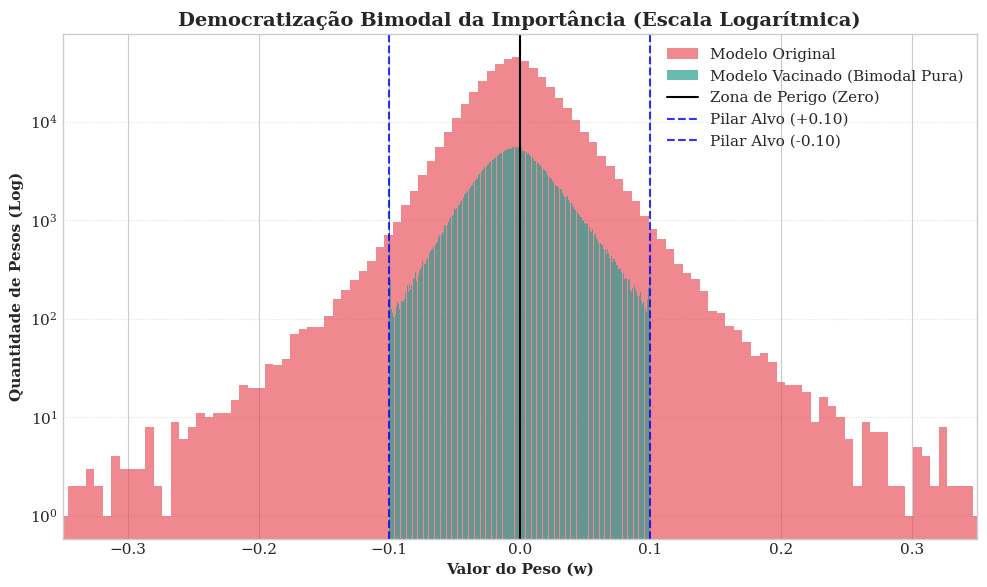


🔍 DIAGNÓSTICO EXATO DE PESOS:
Total de pesos avaliados: 463,792
--------------------------------------------------
Modelo ORIGINAL:
 -> Exatamente 0.0: 0 pesos
 -> Zona de Perigo (±0.01): 131,560 pesos (28.37%)
--------------------------------------------------
Modelo VACINADO (Bimodal):
 -> Exatamente 0.0: 5467 pesos
 -> Zona de Perigo (±0.01): 128,713 pesos (27.75%)
🚀 Gráfico Bimodal salvo em: c:\Users\Herbert\Desktop\LSD\Experimento5\resultados_paper\distribuicao_pesos_bimodal_log_resnet32.png


In [5]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import os

print("[*] Extraindo pesos e gerando Análise de Distribuição Bimodal...")

device = torch.device("cpu")
model_name = "resnet32"  # <--- ATUALIZADO PARA RESNET-32
SAVE_DIR = r"c:\Users\Herbert\Desktop\LSD\Experimento5\resultados_paper"

# ==============================================================================
# CARREGAMENTO DOS MODELOS E EXTRAÇÃO DOS PESOS
# ==============================================================================
# Assume-se que a classe ResNet32 já está na memória pela célula anterior
model_orig = ResNet32(num_classes=10) # <--- ATUALIZADO PARA RESNET-32
model_orig.load_state_dict(torch.load(f"{model_name}_cifar10.pth", map_location=device))

model_vac = ResNet32(num_classes=10) # <--- ATUALIZADO PARA RESNET-32
model_vac.load_state_dict(torch.load(os.path.join(SAVE_DIR, f"{model_name}_cifar10_vacinado.pth"), map_location=device))

pesos_orig = []
pesos_vac = []

# Extrai os pesos originais
for name, module in model_orig.named_modules():
    if isinstance(module, nn.Conv2d):
        pesos_orig.extend(module.weight.data.view(-1).tolist())

# Extrai os pesos vacinados (Agora puxamos TODOS os pesos, sem filtro de zero)
for name, module in model_vac.named_modules():
    if isinstance(module, nn.Conv2d):
        pesos_vac.extend(module.weight.data.view(-1).tolist())

# ==============================================================================
# PLOTAGEM DO GRÁFICO BIMODAL (POÇO DUPLO)
# ==============================================================================
plt.figure(figsize=(10, 6))

plt.hist(pesos_orig, bins=300, log=True, color='#E63946', alpha=0.6, label='Modelo Original')
plt.hist(pesos_vac, bins=300, log=True, color='#2A9D8F', alpha=0.7, label='Modelo Vacinado (Bimodal Pura)')

plt.title('Democratização Bimodal da Importância (Escala Logarítmica)', fontweight='bold', fontsize=14)
plt.xlabel('Valor do Peso (w)', fontweight='bold')
plt.ylabel('Quantidade de Pesos (Log)', fontweight='bold')

# Zoom ampliado para acomodar os pilares em ±0.20
plt.xlim(-0.35, 0.35) 

plt.legend(loc='upper right')
plt.grid(axis='y', linestyle=':', alpha=0.6)

# Marcações visuais da física da rede ajustadas para ALPHA = 0.20
plt.axvline(x=0, color='black', linestyle='-', linewidth=1.5, label='Zona de Perigo (Zero)')
plt.axvline(x=0.10, color='blue', linestyle='--', linewidth=1.5, alpha=0.8, label='Pilar Alvo (+0.10)')
plt.axvline(x=-0.10, color='blue', linestyle='--', linewidth=1.5, alpha=0.8, label='Pilar Alvo (-0.10)')

# Organiza a legenda para não ficar bagunçada com as linhas novas
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper right')

caminho_grafico = os.path.join(SAVE_DIR, f"distribuicao_pesos_bimodal_log_{model_name}.png")
plt.tight_layout()
plt.savefig(caminho_grafico, dpi=300)
plt.show()

# ==============================================================================
# A LUPA MATEMÁTICA: CONTAGEM EXATA DA ZONA DE RISCO
# ==============================================================================
print("\n🔍 DIAGNÓSTICO EXATO DE PESOS:")

# Converte as listas para tensores para facilitar a matemática
t_orig = torch.tensor(pesos_orig)
t_vac = torch.tensor(pesos_vac)

total_pesos = t_orig.numel()

# 1. Pesos no ZERO ABSOLUTO (0.000000)
zeros_orig = (t_orig == 0.0).sum().item()
zeros_vac = (t_vac == 0.0).sum().item()

# 2. Pesos na ZONA DE PERIGO (Ex: entre -0.01 e +0.01)
margem = 0.01
perigo_orig = ((t_orig > -margem) & (t_orig < margem)).sum().item()
perigo_vac = ((t_vac > -margem) & (t_vac < margem)).sum().item()

print(f"Total de pesos avaliados: {total_pesos:,}")
print("-" * 50)
print(f"Modelo ORIGINAL:")
print(f" -> Exatamente 0.0: {zeros_orig} pesos")
print(f" -> Zona de Perigo (±{margem}): {perigo_orig:,} pesos ({(perigo_orig/total_pesos)*100:.2f}%)")
print("-" * 50)
print(f"Modelo VACINADO (Bimodal):")
print(f" -> Exatamente 0.0: {zeros_vac} pesos")
print(f" -> Zona de Perigo (±{margem}): {perigo_vac:,} pesos ({(perigo_vac/total_pesos)*100:.2f}%)")

print(f"🚀 Gráfico Bimodal salvo em: {caminho_grafico}")

Faz extração de features

In [1]:
# -*- coding: utf-8 -*-
# === EXTRAÇÃO DE FEATURES (WEIGHT-LEVEL) - RESNET-32 COMPLETA ===

import os
import math
import random
import numpy as np
import pandas as pd
from collections import OrderedDict
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader

print("\n==================================================================")
print("   INICIANDO EXTRAÇÃO DE FEATURES WEIGHT-LEVEL (RESNET-32 VACINADA)")
print("==================================================================")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "resnet32"
# Atualizado para a pasta do Experimento 5
SAVE_DIR = r"c:\Users\Herbert\Desktop\LSD\Experimento5\resultados_paper"
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_PATH = os.path.join(SAVE_DIR, f"{model_name}_cifar10_vacinado.pth")
OUT_CSV = os.path.join(SAVE_DIR, f"{model_name}_vacinada_FEATURES_WEIGHTLEVEL.csv")

GRAD_BATCHES = 50
GN_BATCHES = 4
INFL_BATCHES = 2
SNIP_BATCHES = 10
BATCH_SIZE = 128
TAU = 1e-4

# --- ARQUITETURA RESNET-32 ---
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion*planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion*planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion*planes)
            )
    def forward(self, x):
        import torch.nn.functional as F
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)

class ResNet_CIFAR(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet_CIFAR, self).__init__()
        self.in_planes = 16
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.layer1 = self._make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 32, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 64, num_blocks[2], stride=2)
        self.linear = nn.Linear(64*block.expansion, num_classes)
    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for s in strides:
            layers.append(block(self.in_planes, planes, s))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)
    def forward(self, x):
        import torch.nn.functional as F
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = F.avg_pool2d(out, 8)
        out = out.view(out.size(0), -1)
        return self.linear(out)

# Na arquitetura CIFAR-10 original, ResNet-32 utiliza 5 blocos por camada [5, 5, 5] (6n+2 = 32)
def ResNet32(num_classes=10):
    return ResNet_CIFAR(BasicBlock, [5, 5, 5], num_classes=num_classes)

# --- FUNÇÕES DE FEATURES (TODAS RESTAURADAS) ---
def get_loaders(batch_size=128):
    tf = T.Compose([T.ToTensor(), T.Normalize((0.4914,0.4822,0.4465), (0.247,0.243,0.261))])
    train_ds = torchvision.datasets.CIFAR10("./data", train=True, transform=tf, download=True)
    test_ds = torchvision.datasets.CIFAR10("./data", train=False, transform=tf, download=True)
    return DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0), DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)

def list_target_weight_params(model):
    return [(name[:-7], name, p) for name, p in model.named_parameters() if name.endswith(".weight") and p.ndim in (2, 4)]

@torch.no_grad()
def calc_times_per_layer(model, device):
    dims_map = {}
    hooks = [m.register_forward_hook(lambda md, i, o, nm=n: dims_map.update({nm: o.shape})) for n, m in model.named_modules() if isinstance(m, (nn.Conv2d, nn.Linear))]
    model.eval()
    model(torch.zeros(1, 3, 32, 32, device=device))
    for h in hooks: h.remove()
    return {name: int(shape[2])*int(shape[3]) if len(shape)==4 else 1 for name, shape in dims_map.items()}

@torch.no_grad()
def abs_value_map(model):
    return {name[:-7]: p.detach().abs().view(-1).cpu().to(torch.float32) for name, p in model.named_parameters() if name.endswith(".weight") and p.ndim in (2,4)}

def fanin_per_layer(model):
    return {n: int(m.in_channels * m.kernel_size[0] * m.kernel_size[1]) if isinstance(m, nn.Conv2d) else int(m.in_features) for n, m in model.named_modules() if isinstance(m, (nn.Conv2d, nn.Linear))}

def fanout_per_layer(model):
    return {n: int(m.out_channels) if isinstance(m, nn.Conv2d) else int(m.out_features) for n, m in model.named_modules() if isinstance(m, (nn.Conv2d, nn.Linear))}

def receptive_field_per_layer(model):
    rf_dict, R, J = {}, 1, 1
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            R = R + (module.kernel_size[0] - 1) * J
            J = J * module.stride[0]
            rf_dict[name] = R
    return rf_dict

@torch.no_grad()
def sign_maps(model):
    sign_map, bin_map = {}, {}
    for name, p in model.named_parameters():
        if name.endswith(".weight") and p.ndim in (2,4):
            layer = name[:-7]
            s = torch.sign(p.detach().view(-1))
            s[s == 0] = 1
            sign_map[layer], bin_map[layer] = s.to(torch.int8).cpu(), ((s + 1) // 2).to(torch.uint8).cpu()
    return sign_map, bin_map

def avg_grad_map(model, train_loader, device, max_batches=50):
    model.train()
    criterion = nn.CrossEntropyLoss()
    targets = [(n, p) for n, p in model.named_parameters() if p.requires_grad and n.endswith(".weight") and p.ndim in (2,4)]
    acc = {n: torch.zeros_like(p) for n, p in targets}
    for i, (x, y) in enumerate(train_loader):
        if i >= max_batches: break
        model.zero_grad()
        criterion(model(x.to(device)), y.to(device)).backward()
        with torch.no_grad():
            for n, p in targets: 
                if p.grad is not None: acc[n] += p.grad
    return {n[:-7]: (acc[n]/max_batches).detach().view(-1).cpu().to(torch.float32) for n in acc}

def diag_gn(model, loader, device, max_batches=4):
    model.eval()
    targets = [(n, p) for n, p in model.named_parameters() if p.requires_grad and n.endswith(".weight") and p.ndim in (2,4)]
    acc = {n: torch.zeros_like(p, dtype=torch.float64) for n, p in targets}
    n_batch = 0
    for n_batch, (imgs, labs) in enumerate(loader, 1):
        if n_batch > max_batches: break
        with torch.set_grad_enabled(True):
            model.zero_grad()
            loss = nn.CrossEntropyLoss()(model(imgs.to(device)), labs.to(device))
            grads = torch.autograd.grad(loss, [p for _, p in targets], create_graph=False)
        for (name, _), g in zip(targets, grads): acc[name] += g.pow(2)
    return {n[:-7]: (acc[n]/n_batch).sqrt().to(torch.float32).view(-1).cpu() for n in acc}

@torch.no_grad()
def magnitude_percentile(model):
    pct_map = {}
    for name, p in model.named_parameters():
        if name.endswith(".weight") and p.ndim in (2,4):
            w = p.abs().flatten()
            N = w.numel()
            idx_sorted = torch.argsort(w, stable=True)
            rank = torch.empty_like(idx_sorted, dtype=torch.int64)
            rank[idx_sorted] = torch.arange(N, device=w.device)
            pct_map[name[:-7]] = (rank.float() / (N - 1)).cpu().to(torch.float32)
    return pct_map

@torch.no_grad()
def weight_energy_map(model):
    w_map = {}
    for name, p in model.named_parameters():
        if name.endswith(".weight") and p.ndim in (2,4):
            w = p.detach()
            e_ch = (w**2).view(w.size(0), -1).sum(dim=1) if w.ndim == 4 else (w**2).sum(dim=1)
            w_map[name[:-7]] = e_ch.repeat_interleave(w.numel() // e_ch.numel()).cpu().to(torch.float32)
    return w_map

@torch.no_grad()
def weight_energy_in_map(model):
    w_map = {}
    for name, p in model.named_parameters():
        if name.endswith(".weight") and p.ndim in (2,4):
            w = p.detach()
            e_in = w.pow(2).sum(dim=(0,2,3)) if w.ndim == 4 else w.pow(2).sum(dim=0)
            e_brd = e_in[None, :, None, None].expand_as(w) if w.ndim == 4 else e_in[None, :].expand_as(w)
            w_map[name[:-7]] = e_brd.contiguous().view(-1).cpu().to(torch.float32)
    return w_map

@torch.no_grad()
def distance_to_center_map(model):
    dist_map = {}
    for name, p in model.named_parameters():
        if not name.endswith(".weight") or p.ndim not in (2,4): continue
        layer = name[:-7]
        if p.ndim == 2:
            dist_map[layer] = torch.zeros(p.numel(), dtype=torch.float32)
            continue
        w = p.detach()
        Cout, Cin, Kh, Kw = w.shape
        cx, cy = (Kw - 1) / 2.0, (Kh - 1) / 2.0
        X, Y = torch.meshgrid(torch.arange(Kw), torch.arange(Kh), indexing="xy")
        dist = torch.sqrt((X - cx)**2 + (Y - cy)**2) / math.sqrt(cx**2 + cy**2)
        dist_map[layer] = dist.expand(Cout, Cin, Kh, Kw).contiguous().view(-1).cpu().to(torch.float32)
    return dist_map

@torch.no_grad()
def layer_hparams(model):
    out = {}
    for name, mod in model.named_modules():
        if isinstance(mod, nn.Conv2d):
            out[name] = (mod.kernel_size[0]*mod.kernel_size[1], mod.stride[0], mod.dilation[0], mod.groups)
        elif isinstance(mod, nn.Linear):
            out[name] = (1, 1, 1, 1)
    return out

@torch.no_grad()
def weight_param_maps(model):
    hp = layer_hparams(model)
    k_map, s_map, d_map, g_map = {}, {}, {}, {}
    for name, p in model.named_parameters():
        if name.endswith(".weight") and p.ndim in (2,4):
            layer = name[:-7]
            if layer in hp:
                k, s, d, g = hp[layer]
                N = p.numel()
                k_map[layer] = torch.full((N,), k, dtype=torch.int32)
                s_map[layer] = torch.full((N,), s, dtype=torch.int32)
                d_map[layer] = torch.full((N,), d, dtype=torch.int32)
                g_map[layer] = torch.full((N,), g, dtype=torch.int32)
    return k_map, s_map, d_map, g_map

@torch.no_grad()
def sparsity_per_weight(model, tau=1e-4):
    w_map = {}
    for name, p in model.named_parameters():
        if name.endswith(".weight") and p.ndim in (2,4):
            layer = name[:-7]
            s = (p.detach().abs() < tau).float().mean().item()
            w_map[layer] = torch.full((p.numel(),), s, dtype=torch.float32)
    return w_map

def influence_score(model, loader, device, max_batches=2):
    model.eval()
    targets = [(n, p) for n, p in model.named_parameters() if p.requires_grad and n.endswith(".weight") and p.ndim in (2,4)]
    accum = {n: torch.zeros_like(p, dtype=torch.float32) for n, p in targets}
    for i, (x, _) in enumerate(loader):
        if i >= max_batches: break
        model.zero_grad()
        grads = torch.autograd.grad(model(x.to(device)).sum(), [p for _, p in targets], retain_graph=False)
        for (n, _), g in zip(targets, grads): accum[n] += g.abs().to(torch.float32)
    return {k[:-7]: (v.flatten().cpu() / max_batches) for k, v in accum.items()}

@torch.no_grad()
def depth_map_per_weight(model):
    layers = [n[:-7] for n, p in model.named_parameters() if n.endswith(".weight") and p.ndim in (2,4)]
    L = len(layers)
    depth = {ly: idx/(L-1) if L > 1 else 0.0 for idx, ly in enumerate(layers)}
    out = {}
    for name, p in model.named_parameters():
        if name.endswith(".weight") and p.ndim in (2,4):
            out[name[:-7]] = torch.full((p.numel(),), depth[name[:-7]], dtype=torch.float32)
    return out

def snip_saliency(model, loader, device, max_batches=10):
    model.train()
    targets = [(n, p) for n, p in model.named_parameters() if p.requires_grad and n.endswith(".weight") and p.ndim in (2,4)]
    acc = {n: torch.zeros_like(p, dtype=torch.float32) for n, p in targets}
    for i, (x, y) in enumerate(loader):
        if i >= max_batches: break
        model.zero_grad()
        loss = nn.CrossEntropyLoss()(model(x.to(device)), y.to(device))
        grads = torch.autograd.grad(loss, [p for _, p in targets], create_graph=False)
        for (n, w), g in zip(targets, grads): acc[n] += (w * g).abs().detach()
    return {n[:-7]: (v.flatten().cpu() / max_batches) for n, v in acc.items()}

def synflow_saliency(model, device):
    model.eval()
    targets = [(n, p) for n, p in model.named_parameters() if p.requires_grad and n.endswith(".weight") and p.ndim in (2,4)]
    originals = [p.data.clone() for _, p in targets]
    for _, p in targets: p.data = p.data.abs()
    out = model(torch.ones(1, 3, 32, 32, device=device)).sum()
    grads = torch.autograd.grad(out, [p for _, p in targets], create_graph=False)
    sal_map = {n[:-7]: (w * g).abs().flatten().to(torch.float32).cpu() for (n, w), g in zip(targets, grads)}
    for (_, p), old in zip(targets, originals): p.data.copy_(old)
    return sal_map

# --- PROCESSO PRINCIPAL ---
if __name__ == "__main__":
    model = ResNet32(num_classes=10).to(device)
    if os.path.exists(MODEL_PATH):
        model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
        print(f"[*] Modelo Vacinado carregado.")
    else: raise SystemExit(f"⚠️ Erro: Arquivo {MODEL_PATH} não encontrado!")
        
    train_loader, test_loader = get_loaders(BATCH_SIZE)

    print("[*] Computando características físicas e estatísticas completas...")
    ct_dict = calc_times_per_layer(model, device)
    abs_map = abs_value_map(model)
    fanin_dict = fanin_per_layer(model)
    fanout_dict = fanout_per_layer(model)
    rf_dict = receptive_field_per_layer(model)
    sgn_map, sgn_bin_map = sign_maps(model)
    grad_map = avg_grad_map(model, train_loader, device, max_batches=GRAD_BATCHES)
    h_map = diag_gn(model, train_loader, device, max_batches=GN_BATCHES)
    pct_map = magnitude_percentile(model)
    eout_map = weight_energy_map(model)
    ein_map = weight_energy_in_map(model)
    dc_map = distance_to_center_map(model)
    k_map, st_map, d_map, g_map = weight_param_maps(model)
    sp_map = sparsity_per_weight(model, tau=TAU)
    infl_map = influence_score(model, test_loader, device, max_batches=INFL_BATCHES)
    depth_map = depth_map_per_weight(model)
    
    print("[*] Computando Saliências...")
    snip_raw = snip_saliency(model, train_loader, device, max_batches=SNIP_BATCHES)
    snip_agg = {k: v.mean().item() for k, v in snip_raw.items()}
    syn_raw = synflow_saliency(model, device)
    syn_agg = {k: v.mean().item() for k, v in syn_raw.items()}

    targets = list_target_weight_params(model)

    out_fields = [
        "layer", "param_index", "gradient", "calc_times", "abs_value",
        "fan_in", "fan_out", "rf_size", "sign", "sign_bin", "hii", "H",
        "pct_mag", "E_out", "E_out_log", "E_in", "E_in_log", "dist_center",
        "k_size", "stride", "dilate", "groups", "sparsity", "s_logit",
        "influence", "influence_log", "depth_norm",
        "snip_saliency", "synflow_saliency", "snip_saliency_log", "synflow_saliency_log"
    ]

    if os.path.exists(OUT_CSV): os.remove(OUT_CSV)
    header_written = False

    for layer, _, p in targets:
        N = p.numel()
        sp = sp_map[layer].numpy()
        sp_clip = np.clip(sp, 1e-8, 1 - 1e-8)
        
        base_df = pd.DataFrame({
            "layer": np.repeat(layer, N),
            "param_index": np.arange(N, dtype=np.int64),
            "gradient": grad_map[layer].numpy(), "calc_times": np.full(N, ct_dict.get(layer, 1)),
            "abs_value": abs_map[layer].numpy(), "fan_in": np.full(N, fanin_dict.get(layer, 0)),
            "fan_out": np.full(N, fanout_dict.get(layer, 0)), "rf_size": np.full(N, rf_dict.get(layer, 1)),
            "sign": sgn_map[layer].numpy(), "sign_bin": sgn_bin_map[layer].numpy(),
            "hii": h_map[layer].numpy(), "H": np.log1p(h_map[layer].numpy()), "pct_mag": pct_map[layer].numpy(),
            "E_out": eout_map[layer].numpy(), "E_out_log": np.log1p(eout_map[layer].numpy()),
            "E_in": ein_map[layer].numpy(), "E_in_log": np.log1p(ein_map[layer].numpy()),
            "dist_center": dc_map[layer].numpy() if layer in dc_map else np.zeros(N),
            "k_size": k_map[layer].numpy() if layer in k_map else np.ones(N),
            "stride": st_map[layer].numpy() if layer in st_map else np.ones(N),
            "dilate": d_map[layer].numpy() if layer in d_map else np.ones(N),
            "groups": g_map[layer].numpy() if layer in g_map else np.ones(N),
            "sparsity": sp, "s_logit": np.log(sp_clip / (1 - sp_clip)),
            "influence": infl_map[layer].numpy(), "influence_log": np.log1p(infl_map[layer].numpy()),
            "depth_norm": depth_map[layer].numpy(),
            "snip_saliency": np.full(N, snip_agg.get(layer, 0.0)), "snip_saliency_log": np.log1p(np.full(N, snip_agg.get(layer, 0.0))),
            "synflow_saliency": np.full(N, syn_agg.get(layer, 0.0)), "synflow_saliency_log": np.log1p(np.full(N, syn_agg.get(layer, 0.0)))
        })

        base_df = base_df[out_fields]
        base_df.to_csv(OUT_CSV, mode="a", header=(not header_written), index=False, float_format="%.8e")
        header_written = True

        print(f" -> Layer '{layer}' concluída.")

    print(f"\n🚀 EXTRAÇÃO CONCLUÍDA! Pronto para rodar o Predictor usando '{OUT_CSV}'.")


   INICIANDO EXTRAÇÃO DE FEATURES WEIGHT-LEVEL (RESNET-32 VACINADA)
[*] Modelo Vacinado carregado.


c:\Users\Herbert\Desktop\LSD\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


[*] Computando características físicas e estatísticas completas...
[*] Computando Saliências...
 -> Layer 'conv1' concluída.
 -> Layer 'layer1.0.conv1' concluída.
 -> Layer 'layer1.0.conv2' concluída.
 -> Layer 'layer1.1.conv1' concluída.
 -> Layer 'layer1.1.conv2' concluída.
 -> Layer 'layer1.2.conv1' concluída.
 -> Layer 'layer1.2.conv2' concluída.
 -> Layer 'layer1.3.conv1' concluída.
 -> Layer 'layer1.3.conv2' concluída.
 -> Layer 'layer1.4.conv1' concluída.
 -> Layer 'layer1.4.conv2' concluída.
 -> Layer 'layer2.0.conv1' concluída.
 -> Layer 'layer2.0.conv2' concluída.
 -> Layer 'layer2.0.shortcut.0' concluída.
 -> Layer 'layer2.1.conv1' concluída.
 -> Layer 'layer2.1.conv2' concluída.
 -> Layer 'layer2.2.conv1' concluída.
 -> Layer 'layer2.2.conv2' concluída.
 -> Layer 'layer2.3.conv1' concluída.
 -> Layer 'layer2.3.conv2' concluída.
 -> Layer 'layer2.4.conv1' concluída.
 -> Layer 'layer2.4.conv2' concluída.
 -> Layer 'layer3.0.conv1' concluída.
 -> Layer 'layer3.0.conv2' concluí

Gera o output da previsão de vulnerabilidade da rede vacinada

In [2]:
# -*- coding: utf-8 -*-
# === PREDIÇÃO DE VULNERABILIDADE (MODO CIRURGIA INTELIGENTE V6 - WEIGHT-LEVEL) ===

import os
import sys
import types
import pandas as pd
import numpy as np
import pickle
import joblib

# ---------------------------------------------------------
# HACK FORENSE 1: Recriando classes e módulos extintos
# ---------------------------------------------------------
import sklearn.compose._column_transformer
class _RemainderColsList(list):
    pass
sklearn.compose._column_transformer._RemainderColsList = _RemainderColsList

fake_module = types.ModuleType('Pipeline')
sys.modules['Pipeline'] = fake_module
try:
    from sklearn.pipeline import Pipeline as SklearnPipeline
    fake_module.Pipeline = SklearnPipeline
except ImportError:
    pass

# ---------------------------------------------------------
# HACK FORENSE 2: Varredura de Memória Recursiva Inteligente
# ---------------------------------------------------------
def varredura_profunda(obj, visitados=None):
    if visitados is None:
        visitados = set()
        
    if id(obj) in visitados:
        return
    visitados.add(id(obj))
    
    if obj.__class__.__name__ == 'SimpleImputer':
        tipo_original = np.dtype('float64')
        if hasattr(obj, 'statistics_') and obj.statistics_ is not None:
            try:
                tipo_original = obj.statistics_.dtype
            except Exception:
                pass
        else:
            if hasattr(obj, 'fill_value') and isinstance(obj.fill_value, str):
                tipo_original = np.dtype('object')

        if not hasattr(obj, '_fill_dtype'):
            obj._fill_dtype = tipo_original
        if not hasattr(obj, '_fit_dtype'):
            obj._fit_dtype = tipo_original
        if not hasattr(obj, 'keep_empty_features'):
            obj.keep_empty_features = False

    if isinstance(obj, dict):
        for v in obj.values():
            varredura_profunda(v, visitados)
            
    elif isinstance(obj, (list, tuple)):
        for item in obj:
            varredura_profunda(item, visitados)
            
    elif hasattr(obj, '__dict__'):
        for key, val in vars(obj).items():
            varredura_profunda(val, visitados)
# ---------------------------------------------------------

print("\n==================================================================")
print("   INICIANDO PIPELINE DE PREDIÇÃO DE VULNERABILIDADE (RESNET-32)")
print("==================================================================")

# ---> CORREÇÃO AQUI: Apontando para o Experimento 5 <---
BASE_DIR = r"c:\Users\Herbert\Desktop\LSD\Experimento5"
SAVE_DIR = os.path.join(BASE_DIR, "resultados_paper")

# ---> CORREÇÃO AQUI: Nomes da ResNet-32 <---
CSV_ENTRADA = os.path.join(SAVE_DIR, "resnet32_vacinada_FEATURES_WEIGHTLEVEL.csv")
MODELO_PKL = os.path.join(BASE_DIR, "modelo_final_resnet32_fbeta1.0.pkl")
CSV_SAIDA = os.path.join(SAVE_DIR, "output2.csv")

print(f"[*] Carregando banco de dados de features...\n    -> {CSV_ENTRADA}")
if not os.path.exists(CSV_ENTRADA):
    raise SystemExit("⚠️ Erro: CSV de features não encontrado. Verifique se o nome está correto.")

df = pd.read_csv(CSV_ENTRADA)
print(f"    -> Concluído! {len(df):,} linhas carregadas.")

print("[*] Tratando valores numéricos problemáticos (infinitos)...")
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print("    -> Tratamento concluído.")

print(f"\n[*] Carregando modelo preditor (.pkl)...\n    -> {MODELO_PKL}")
if not os.path.exists(MODELO_PKL):
    raise SystemExit("⚠️ Erro: Arquivo do modelo .pkl não encontrado.")

try:
    try:
        modelo = joblib.load(MODELO_PKL)
    except Exception:
        with open(MODELO_PKL, 'rb') as f:
            modelo = pickle.load(f)
    print("    -> Sucesso! Arquivo .pkl desempacotado.")
    
    if isinstance(modelo, dict):
        modelo_real = None
        for chave, valor in modelo.items():
            if hasattr(valor, 'predict'):
                modelo_real = valor
                break
        if modelo_real is None:
            raise SystemExit("⚠️ Erro: Nenhuma chave contém um modelo preditivo.")
        modelo = modelo_real 
        
except Exception as e:
    print(f"\n❌ FALHA CRÍTICA AO ABRIR O MODELO: {e}")
    raise SystemExit

print("\n[*] Realizando cirurgia inteligente no modelo...")
varredura_profunda(modelo)
print("    -> Todos os 'SimpleImputers' foram vacinados com seus tipos originais!")

print("\n[*] Iniciando inferência de vulnerabilidade...")

try:
    predicoes = modelo.predict_proba(df)[:, 1] 
    print("    -> 'predict_proba' utilizado com sucesso.")
except AttributeError:
    predicoes = modelo.predict(df)
    print("    -> 'predict' utilizado com sucesso.")

df['vulnerability_pred'] = predicoes

print(f"\n[*] Salvando resultados no formato final...\n    -> {CSV_SAIDA}")
df.to_csv(CSV_SAIDA, index=False)

print("\n🚀 PIPELINE CONCLUÍDO COM SUCESSO! O 'output2.csv' está pronto para o Experimento 5.")


   INICIANDO PIPELINE DE PREDIÇÃO DE VULNERABILIDADE (RESNET-32)
[*] Carregando banco de dados de features...
    -> c:\Users\Herbert\Desktop\LSD\Experimento5\resultados_paper\resnet32_vacinada_FEATURES_WEIGHTLEVEL.csv
    -> Concluído! 464,432 linhas carregadas.
[*] Tratando valores numéricos problemáticos (infinitos)...
    -> Tratamento concluído.

[*] Carregando modelo preditor (.pkl)...
    -> c:\Users\Herbert\Desktop\LSD\Experimento5\modelo_final_resnet32_fbeta1.0.pkl


c:\Users\Herbert\Desktop\LSD\venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Herbert\Desktop\LSD\venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Herbert\Desktop\LSD\venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.6.1 when using version 1.8.0. This mi

    -> Sucesso! Arquivo .pkl desempacotado.

[*] Realizando cirurgia inteligente no modelo...
    -> Todos os 'SimpleImputers' foram vacinados com seus tipos originais!

[*] Iniciando inferência de vulnerabilidade...
    -> 'predict_proba' utilizado com sucesso.

[*] Salvando resultados no formato final...
    -> c:\Users\Herbert\Desktop\LSD\Experimento5\resultados_paper\output2.csv

🚀 PIPELINE CONCLUÍDO COM SUCESSO! O 'output2.csv' está pronto para o Experimento 5.


Compara a resistência das duas redes


   INICIANDO ANÁLISE COMPARATIVA (BASELINE vs VACINADO - EXPERIMENTO 5)
[*] Verificando arquivos...
[*] Carregando e sincronizando os bancos de dados de predição...
    -> Concluído! 464,432 pesos comparados perfeitamente.

[*] Analisando a mudança de alvos do Algoritmo Genético (Top 120)...
    -> Média de vuln. Top 120 (Baseline): 0.7552
    -> Média de vuln. Top 120 (Vacinado): 0.4756
    -> Queda absoluta na severidade: 0.2796
    -> 25/120 alvos se mantiveram iguais.
    -> O Algoritmo Genético terá que buscar 79.2% de alvos NOVOS no modelo vacinado.

[*] Média Global de Vulnerabilidade da Rede:
    -> Baseline: 0.00094
    -> Vacinado: 0.00164

[*] Gerando gráficos comparativos...


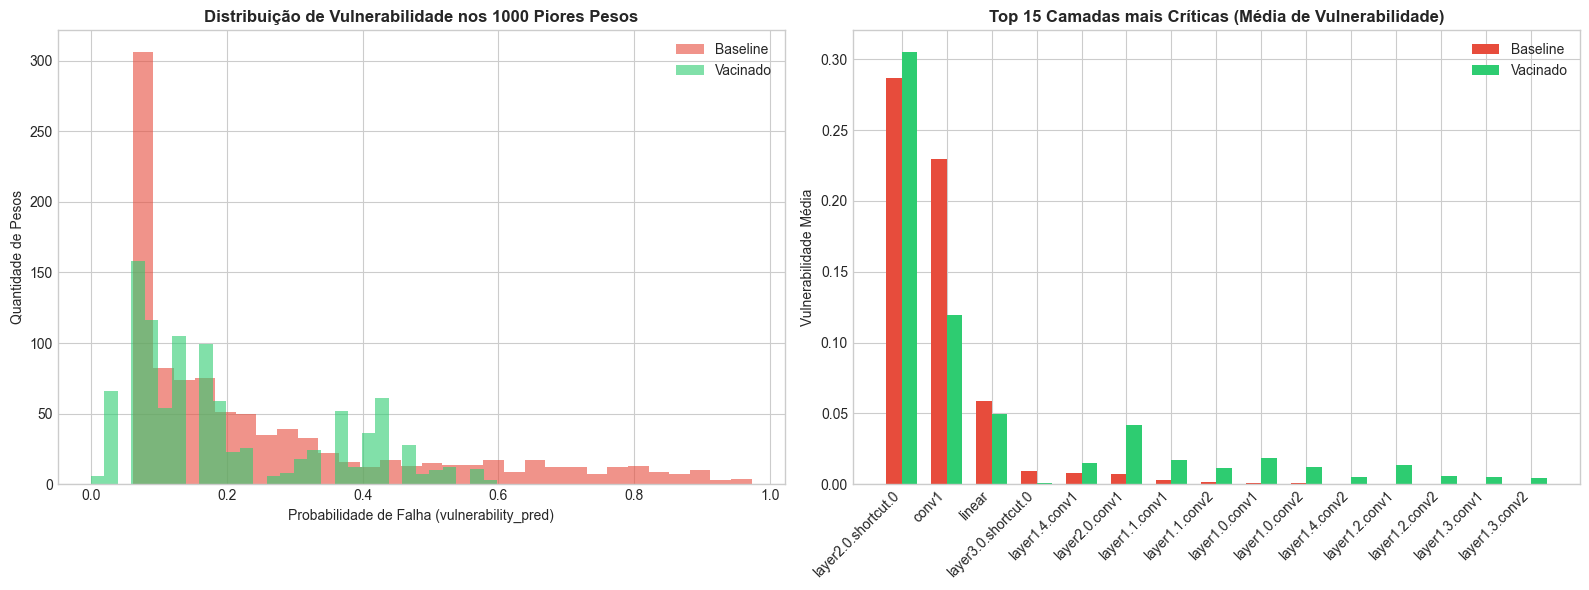

In [3]:
# -*- coding: utf-8 -*-
# === COMPARAÇÃO DE VULNERABILIDADE: BASELINE vs VACINADO (WEIGHT-LEVEL) ===

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("\n==================================================================")
print("   INICIANDO ANÁLISE COMPARATIVA (BASELINE vs VACINADO - EXPERIMENTO 5)")
print("==================================================================")

# ---> CORREÇÃO AQUI: Apontando para o Experimento 5 <---
BASE_DIR = r"c:\Users\Herbert\Desktop\LSD\Experimento5"
SAVE_DIR = os.path.join(BASE_DIR, "resultados_paper")

CSV_BASELINE = os.path.join(BASE_DIR, "output.csv")    
CSV_VACINADO = os.path.join(SAVE_DIR, "output2.csv")   

print("[*] Verificando arquivos...")
if not os.path.exists(CSV_BASELINE): raise SystemExit(f"⚠️ Erro: Não encontrei {CSV_BASELINE}")
if not os.path.exists(CSV_VACINADO): raise SystemExit(f"⚠️ Erro: Não encontrei {CSV_VACINADO}")

# ==============================================================================
print("[*] Carregando e sincronizando os bancos de dados de predição...")
df_base = pd.read_csv(CSV_BASELINE)
df_vac = pd.read_csv(CSV_VACINADO)

# Agora sabemos que a comparação é puramente por Peso (Layer + Param_index)
chaves = ['layer', 'param_index']

df_base_min = df_base[chaves + ['vulnerability_pred']].rename(columns={'vulnerability_pred': 'vuln_base'})
df_vac_min = df_vac[chaves + ['vulnerability_pred']].rename(columns={'vulnerability_pred': 'vuln_vac'})

df_comp = pd.merge(df_base_min, df_vac_min, on=chaves, how='inner')

if len(df_comp) == 0:
    raise SystemExit("⚠️ Erro: O Merge resultou em 0 linhas. Os arquivos não possuem os mesmos pesos.")

df_comp['delta_absoluto'] = df_comp['vuln_base'] - df_comp['vuln_vac']
print(f"    -> Concluído! {len(df_comp):,} pesos comparados perfeitamente.")

# ==============================================================================
print("\n[*] Analisando a mudança de alvos do Algoritmo Genético (Top 120)...")
top120_base = df_comp.nlargest(120, 'vuln_base')
top120_vac = df_comp.nlargest(120, 'vuln_vac')

sobreposicao = pd.merge(top120_base[chaves], top120_vac[chaves], on=chaves, how='inner')
qtd_sobreposicao = len(sobreposicao)
taxa_mudanca = ((120 - qtd_sobreposicao) / 120) * 100

print(f"    -> Média de vuln. Top 120 (Baseline): {top120_base['vuln_base'].mean():.4f}")
print(f"    -> Média de vuln. Top 120 (Vacinado): {top120_vac['vuln_vac'].mean():.4f}")
print(f"    -> Queda absoluta na severidade: {top120_base['vuln_base'].mean() - top120_vac['vuln_vac'].mean():.4f}")
print(f"    -> {qtd_sobreposicao}/120 alvos se mantiveram iguais.")
print(f"    -> O Algoritmo Genético terá que buscar {taxa_mudanca:.1f}% de alvos NOVOS no modelo vacinado.")

# ==============================================================================
media_base = df_comp['vuln_base'].mean()
media_vac = df_comp['vuln_vac'].mean()
print(f"\n[*] Média Global de Vulnerabilidade da Rede:")
print(f"    -> Baseline: {media_base:.5f}")
print(f"    -> Vacinado: {media_vac:.5f}")

# ==============================================================================
print("\n[*] Gerando gráficos comparativos...")
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

top1000_comp = df_comp.nlargest(1000, 'vuln_base')
ax1.hist(top1000_comp['vuln_base'], bins=30, alpha=0.6, label='Baseline', color='#e74c3c')
ax1.hist(top1000_comp['vuln_vac'], bins=30, alpha=0.6, label='Vacinado', color='#2ecc71')
ax1.set_title('Distribuição de Vulnerabilidade nos 1000 Piores Pesos', fontsize=12, fontweight='bold')
ax1.set_xlabel('Probabilidade de Falha (vulnerability_pred)')
ax1.set_ylabel('Quantidade de Pesos')
ax1.legend()

layer_comp = df_comp.groupby('layer')[['vuln_base', 'vuln_vac']].mean().reset_index()
layer_comp['max_vuln'] = layer_comp[['vuln_base', 'vuln_vac']].max(axis=1)
layer_comp = layer_comp.nlargest(15, 'max_vuln').sort_values('vuln_base', ascending=False)

x = np.arange(len(layer_comp['layer']))
width = 0.35
ax2.bar(x - width/2, layer_comp['vuln_base'], width, label='Baseline', color='#e74c3c')
ax2.bar(x + width/2, layer_comp['vuln_vac'], width, label='Vacinado', color='#2ecc71')

ax2.set_title('Top 15 Camadas mais Críticas (Média de Vulnerabilidade)', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(layer_comp['layer'], rotation=45, ha='right')
ax2.set_ylabel('Vulnerabilidade Média')
ax2.legend()
plt.tight_layout()

GRAFICO_IMG = os.path.join(SAVE_DIR, "grafico_comparativo_baseline_vacinado.png")
plt.savefig(GRAFICO_IMG, dpi=300, bbox_inches='tight')
plt.show()

RELATORIO_CSV = os.path.join(SAVE_DIR, "relatorio_comparativo_camadas.csv")
layer_comp.drop(columns=['max_vuln']).to_csv(RELATORIO_CSV, index=False)

Algorítmo genético 2


   INICIANDO ATAQUE (CENÁRIO 3) E CONCATENAÇÃO DE RESULTADOS

[*] Carregando Datasets na Memória (Sonda de 512 imagens)...


c:\Users\Herbert\Desktop\LSD\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")



[*] Recuperando resultados do Algoritmo Genético Anterior...
    -> Variáveis RAM ausentes. Recalculando via planilhas de flips salvos...
    -> Sucesso! Acurácias recalculadas a partir dos arquivos CSVs.
       Cenário 1: 53.12%, Cenário 2: 75.59%
[*] Lendo os Novos Alvos do output2.csv...

--- INICIANDO CAÇADA EVOLUTIVA PARA: VACINADO (Novos Alvos) ---
[*] Acurácia Inicial (Sem Ataque): 91.02%
    -> Gen 1: Novo pior ataque! Acurácia caiu para: 89.65% (usando 4 flips)
    -> Gen 2: Novo pior ataque! Acurácia caiu para: 88.67% (usando 6 flips)
    -> Gen 4: Novo pior ataque! Acurácia caiu para: 87.11% (usando 6 flips)
    -> Gen 11: Novo pior ataque! Acurácia caiu para: 86.33% (usando 6 flips)
[*] Tempo do AG: 397.34s
    💾 Planilha salva em: c:\Users\Herbert\Desktop\LSD\Experimento5\resultados_paper\flips_VACINADO_Novos_Alvos_resnet32.csv
✅ Caçada Finalizada! Acurácia Final (VACINADO (Novos Alvos)): 86.33%

[*] Gerando Gráfico do Ataque Adaptativo Triplo...


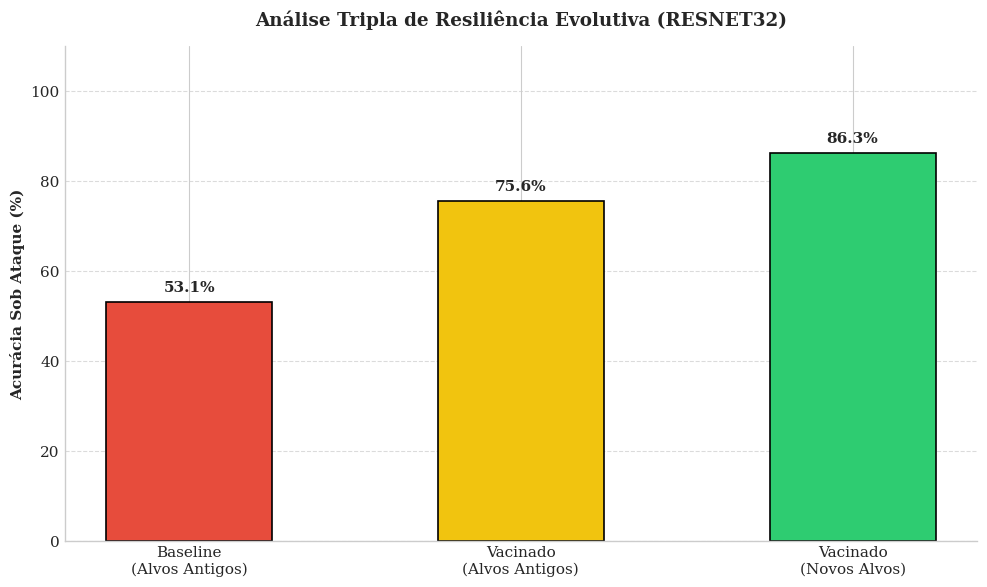


🚀 EXPERIMENTO GENÉTICO CONCLUÍDO! Gráfico salvo em: c:\Users\Herbert\Desktop\LSD\Experimento5\resultados_paper\grafico_ag_triplo_final_resnet32.png


In [4]:
# -*- coding: utf-8 -*-
# === ATAQUE ADAPTATIVO: CENÁRIO 3 + CONCATENAÇÃO DE RESULTADOS (RESNET-32) ===

import os
import random
import time
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

print("\n==================================================================")
print("   INICIANDO ATAQUE (CENÁRIO 3) E CONCATENAÇÃO DE RESULTADOS")
print("==================================================================")

# ==============================================================================
# IMPLEMENTAÇÃO DA RESNET-32
# ==============================================================================
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion*planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion*planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion*planes)
            )
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)

class ResNet_CIFAR(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet_CIFAR, self).__init__()
        self.in_planes = 16
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.layer1 = self._make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 32, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 64, num_blocks[2], stride=2)
        self.linear = nn.Linear(64*block.expansion, num_classes)
    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for s in strides:
            layers.append(block(self.in_planes, planes, s))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = F.avg_pool2d(out, 8)
        out = out.view(out.size(0), -1)
        return self.linear(out)

# ---> CORREÇÃO AQUI: ResNet-32 tem blocos [5, 5, 5] <---
def ResNet32(num_classes=10):
    return ResNet_CIFAR(BasicBlock, [5, 5, 5], num_classes=num_classes)

# ==============================================================================
# CONFIGURAÇÕES GERAIS E PATHS
# ==============================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "resnet32"  
BASE_DIR = r"c:\Users\Herbert\Desktop\LSD\Experimento5"
SAVE_DIR = os.path.join(BASE_DIR, "resultados_paper")
os.makedirs(SAVE_DIR, exist_ok=True)

caminho_modelo_limpo = os.path.join(BASE_DIR, f"{model_name}_cifar10.pth")
caminho_modelo_vacinado = os.path.join(SAVE_DIR, f"{model_name}_cifar10_vacinado.pth")
csv_vacinado = os.path.join(SAVE_DIR, "output2.csv") # Output corrigido (Weight-Level)

# Parâmetros do AG 
BATCH_SIZE_GPU = 128
N_INITIAL_CANDIDATES = 120 
GA_NUM_GENERATIONS = 20   
GA_POPULATION_SIZE = 40
GA_NUM_ELITES = 4
GA_MUTATION_RATE = 0.025
GA_TOURNAMENT_SIZE = 3
GA_INITIAL_FLIP_PROB = 0.05
GA_MAX_FLIPS = 6
GA_TARGET_ACCURACY = 0.15 
BIT_TO_FLIP = 7  # MSB
GA_ENABLE_POST_PRUNING = False

# ==============================================================================
# PREPARAÇÃO DE DADOS E AVALIADOR EXACT MODE
# ==============================================================================
print("\n[*] Carregando Datasets na Memória (Sonda de 512 imagens)...")
normalize = transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
test_tf = transforms.Compose([transforms.ToTensor(), normalize])
test_ds = datasets.CIFAR10("./data", train=False, transform=test_tf, download=False)
full_loader = DataLoader(Subset(test_ds, range(512)), batch_size=BATCH_SIZE_GPU, shuffle=False)

def cache_loader_to_device(loader, device):
    xs, ys = [], []
    for x, y in loader:
        xs.append(x); ys.append(y)
    return torch.cat(xs, dim=0).to(device), torch.cat(ys, dim=0).to(device)

cached_full = cache_loader_to_device(full_loader, device)

def manual_eval_acc(model, flips_list, cached_data, batch_size=BATCH_SIZE_GPU):
    orig_weights = {}
    with torch.no_grad():
        for name, module in model.named_modules():
            if isinstance(module, (nn.Conv2d, nn.Linear)):
                orig_weights[name] = module.weight.data.clone()
                w = module.weight.data
                w_max = w.abs().max().item()
                scale = w_max / 127.0 if w_max > 0 else 1.0
                w_q = torch.round(w / scale).clamp(-128, 127)
                module.weight.data.copy_(w_q * scale)
        
        flips_by_layer = {}
        for f in flips_list:
            flips_by_layer.setdefault(f["layer"], []).append(int(f["param_index"]))
            
        for layer_name, positions in flips_by_layer.items():
            mod = dict(model.named_modules())[layer_name]
            w = orig_weights[layer_name]
            w_max = w.abs().max().item()
            scale = w_max / 127.0 if w_max > 0 else 1.0
            
            w_q = torch.round(w / scale).clamp(-128, 127).to(torch.int32)
            w_flat = w_q.view(-1)
            
            for idx in positions:
                val = w_flat[idx].item()
                u_val = val & 0xFF
                u_val ^= (1 << BIT_TO_FLIP)
                q_flip = u_val if u_val < 128 else u_val - 256
                w_flat[idx] = q_flip
                
            mod.weight.data.copy_(w_flat.view(w_q.shape).float() * scale)
            
    model.eval()
    X, Y = cached_data
    total = Y.size(0)
    correct = 0
    with torch.no_grad():
        for i in range(0, total, batch_size):
            xb, yb = X[i:i+batch_size], Y[i:i+batch_size]
            pred = model(xb).argmax(dim=1)
            correct += (pred == yb).sum().item()
            
    with torch.no_grad():
        for name, module in model.named_modules():
            if isinstance(module, (nn.Conv2d, nn.Linear)):
                module.weight.data.copy_(orig_weights[name])
                
    return correct / max(total, 1)

# ==============================================================================
# RECUPERAR CENÁRIOS 1 E 2 (Baseline e Vacinado nos Alvos Antigos)
# ==============================================================================
print("\n[*] Recuperando resultados do Algoritmo Genético Anterior...")

acc_1, acc_2 = None, None

# Tenta carregar os CSVs de flips se as variáveis não estiverem na memória
file_orig = os.path.join(SAVE_DIR, f"flips_MODELO_ORIGINAL_{model_name}.csv")
file_vac = os.path.join(SAVE_DIR, f"flips_MODELO_VACINADO_Bimodal_+_QAT_{model_name}.csv")

# Tenta corrigir nome do arquivo caso o OS tenha salvo com os parênteses
if not os.path.exists(file_vac):
    file_vac = os.path.join(SAVE_DIR, f"flips_MODELO_VACINADO_(Bimodal_+_QAT)_{model_name}.csv")

if 'acc_original' in globals() and 'acc_vacinada' in globals():
    acc_1 = acc_original
    acc_2 = acc_vacinada
    print(f"    -> Sucesso! Acurácias recuperadas da memória RAM do Jupyter.\n       Cenário 1: {acc_1:.2f}%, Cenário 2: {acc_2:.2f}%")
else:
    print("    -> Variáveis RAM ausentes. Recalculando via planilhas de flips salvos...")
    if os.path.exists(file_orig) and os.path.exists(file_vac):
        # Avaliar Modelo Original (ResNet-32)
        m_orig = ResNet32().to(device)
        m_orig.load_state_dict(torch.load(caminho_modelo_limpo, map_location=device))
        acc_1 = manual_eval_acc(m_orig, pd.read_csv(file_orig).to_dict('records'), cached_full) * 100
        
        # Avaliar Modelo Vacinado (Cenário 2)
        m_vac = ResNet32().to(device)
        m_vac.load_state_dict(torch.load(caminho_modelo_vacinado, map_location=device))
        acc_2 = manual_eval_acc(m_vac, pd.read_csv(file_vac).to_dict('records'), cached_full) * 100
        
        print(f"    -> Sucesso! Acurácias recalculadas a partir dos arquivos CSVs.\n       Cenário 1: {acc_1:.2f}%, Cenário 2: {acc_2:.2f}%")
    else:
        raise SystemExit(f"⚠️ Erro: Arquivos de flips anteriores não encontrados em {SAVE_DIR}. \nVocê precisa rodar a célula de ataque genético TRIPLO (sem cache) primeiro para a ResNet-32 para gerar o Baseline.")

# ==============================================================================
# EXECUTAR CENÁRIO 3: VACINADO VS NOVOS ALVOS (OUTPUT2.CSV)
# ==============================================================================
def create_initial_population(pop_size, chrom_length, flip_prob, max_flips):
    population = []
    for _ in range(pop_size):
        chrom = np.random.choice([0, 1], size=(chrom_length,), p=[1-flip_prob, flip_prob])
        while np.sum(chrom) > max_flips:
            ones = np.where(chrom == 1)[0]
            if len(ones) > 0: chrom[np.random.choice(ones)] = 0
            else: break
        population.append(chrom.astype(np.int8))
    return population

def translate_chromosome_to_flips(chromosome, candidate_pool):
    return [candidate_pool[i] for i in np.where(chromosome == 1)[0]]

def evaluate_fitness_manual(chromosome, candidate_pool, model, cached_data, baseline_acc):
    flips = translate_chromosome_to_flips(chromosome, candidate_pool)
    if not flips: return 0.0, baseline_acc
    acc_i = manual_eval_acc(model, flips, cached_data)
    return baseline_acc - acc_i, acc_i

def selection(pop_with_fitness, tour_size):
    contenders = random.sample(pop_with_fitness, min(tour_size, len(pop_with_fitness)))
    contenders.sort(key=lambda x: x[0], reverse=True)
    return contenders[0][2]

def crossover(p1, p2, max_flips):
    if len(p1) < 2: return p1.copy(), p2.copy()
    cpt = random.randint(1, len(p1) - 1)
    c1 = np.concatenate([p1[:cpt], p2[cpt:]])
    c2 = np.concatenate([p2[:cpt], p1[cpt:]])
    for child in [c1, c2]:
        while np.sum(child) > max_flips:
            ones = np.where(child == 1)[0]
            if len(ones) > 0: child[np.random.choice(ones)] = 0
            else: break
    return c1, c2

def mutation(chromosome, mut_rate, max_flips):
    mask = np.random.random(len(chromosome)) < mut_rate
    mutated = chromosome.copy()
    mutated[mask] = 1 - mutated[mask]
    if np.sum(mutated) > max_flips:
        ones = np.where(mutated == 1)[0]
        to_remove = len(ones) - max_flips
        if to_remove > 0: mutated[np.random.choice(ones, to_remove, replace=False)] = 0
    return mutated

def prune_flip_set_keep_target_manual(model, flips_list, cached_data, target_acc):
    if not flips_list or len(flips_list) <= 1: return flips_list
    if manual_eval_acc(model, flips_list, cached_data) >= target_acc: return flips_list
    current = flips_list[:]
    vuln_of = lambda f: float(f.get("vulnerability_pred", 0.0))
    while len(current) > 1:
        n = len(current)
        ordered_indices = sorted(range(n), key=lambda i: vuln_of(current[i]), reverse=False)
        best_trial, best_trial_acc = None, None
        for idx_remove in ordered_indices:
            trial = current[:idx_remove] + current[idx_remove+1:]
            acc_t = manual_eval_acc(model, trial, cached_data)
            if acc_t < target_acc:
                if (best_trial_acc is None) or (acc_t < best_trial_acc):
                    best_trial_acc, best_trial = acc_t, trial
        if best_trial is not None: current = best_trial
        else: break
    return current

def executar_cacada_genetica(modelo_path, nome_modelo, candidate_pool):
    print(f"\n--- INICIANDO CAÇADA EVOLUTIVA PARA: {nome_modelo} ---")
    model = ResNet32().to(device)
    model.load_state_dict(torch.load(modelo_path, map_location=device))
    model.eval()

    acc_quant_baseline = manual_eval_acc(model, [], cached_full)
    print(f"[*] Acurácia Inicial (Sem Ataque): {acc_quant_baseline*100:.2f}%")

    population = create_initial_population(GA_POPULATION_SIZE, len(candidate_pool), GA_INITIAL_FLIP_PROB, GA_MAX_FLIPS)
    best_overall_chrom, best_overall_fit = None, -999.0

    start_time = time.time()
    for gen in range(GA_NUM_GENERATIONS):
        pop_fit = []
        for chrom in population:
            fit, acc_full = evaluate_fitness_manual(chrom, candidate_pool, model, cached_full, acc_quant_baseline)
            pop_fit.append((fit, acc_full, chrom))
            
        pop_fit.sort(key=lambda x: x[0], reverse=True)
        gen_best_fit, gen_best_acc, gen_best_chrom = pop_fit[0]

        if gen_best_fit > best_overall_fit:
            best_overall_fit = gen_best_fit
            best_overall_chrom = gen_best_chrom.copy()
            print(f"    -> Gen {gen+1}: Novo pior ataque! Acurácia caiu para: {gen_best_acc*100:.2f}% (usando {int(np.sum(best_overall_chrom))} flips)")
            if gen_best_acc < GA_TARGET_ACCURACY:
                print("    -> TARGET DE DESTRUIÇÃO ATINGIDO!")
                break

        new_pop = [x[2] for x in pop_fit[:GA_NUM_ELITES]]
        while len(new_pop) < GA_POPULATION_SIZE:
            p1 = selection(pop_fit, GA_TOURNAMENT_SIZE)
            p2 = selection(pop_fit, GA_TOURNAMENT_SIZE)
            c1, c2 = crossover(p1, p2, GA_MAX_FLIPS)
            new_pop.append(mutation(c1, GA_MUTATION_RATE, GA_MAX_FLIPS))
            if len(new_pop) < GA_POPULATION_SIZE: new_pop.append(mutation(c2, GA_MUTATION_RATE, GA_MAX_FLIPS))
        population = new_pop

    print(f"[*] Tempo do AG: {time.time() - start_time:.2f}s")
    best_flips = translate_chromosome_to_flips(best_overall_chrom, candidate_pool)
    final_acc = manual_eval_acc(model, best_flips, cached_full)

    if GA_ENABLE_POST_PRUNING and len(best_flips) > 1:
        print("    [*] Poda ativada. Limpando flips desnecessários...")
        pruned_flips = prune_flip_set_keep_target_manual(model, best_flips, cached_full, final_acc + 0.05)
        if len(pruned_flips) < len(best_flips):
            print(f"    -> PRUNE EFICAZ: Flips reduzidos de {len(best_flips)} para {len(pruned_flips)}!")
            best_flips = pruned_flips
            final_acc = manual_eval_acc(model, best_flips, cached_full)

    if best_flips:
        nome_safe = nome_modelo.replace(' ', '_').replace('(', '').replace(')', '')
        caminho_csv = os.path.join(SAVE_DIR, f"flips_{nome_safe}_{model_name}.csv")
        df_res = pd.DataFrame(best_flips)
        if 'vulnerability_pred' in df_res.columns: df_res = df_res.sort_values('vulnerability_pred', ascending=False)
        df_res.to_csv(caminho_csv, index=False)
        print(f"    💾 Planilha salva em: {caminho_csv}")

    print(f"✅ Caçada Finalizada! Acurácia Final ({nome_modelo}): {final_acc*100:.2f}%\n")
    return final_acc*100


print(f"[*] Lendo os Novos Alvos do output2.csv...")
df_vac = pd.read_csv(csv_vacinado)
# Puxando as 120 features reais weight-level que acabamos de gerar
pool_vacinado = df_vac.nlargest(N_INITIAL_CANDIDATES, 'vulnerability_pred').to_dict('records')

# RODA O ATAQUE APENAS PARA O TERCEIRO CENÁRIO
acc_3 = executar_cacada_genetica(caminho_modelo_vacinado, "VACINADO (Novos Alvos)", pool_vacinado)

# ==============================================================================
# GRÁFICO FINAL TRIPLO
# ==============================================================================
print("[*] Gerando Gráfico do Ataque Adaptativo Triplo...")
plt.rcParams.update({'font.size': 11, 'font.family': 'serif'})
fig, ax = plt.subplots(figsize=(10, 6))

cenarios = [
    'Baseline\n(Alvos Antigos)', 
    'Vacinado\n(Alvos Antigos)', 
    'Vacinado\n(Novos Alvos)'
]
acuracias = [acc_1, acc_2, acc_3]
cores = ['#e74c3c', '#f1c40f', '#2ecc71'] 

barras = ax.bar(cenarios, acuracias, color=cores, width=0.5, edgecolor='black', linewidth=1.2)

for barra in barras:
    altura = barra.get_height()
    ax.annotate(f'{altura:.1f}%', xy=(barra.get_x() + barra.get_width() / 2, altura),
                xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Acurácia Sob Ataque (%)', fontweight='bold')
ax.set_title(f'Análise Tripla de Resiliência Evolutiva ({model_name.upper()})', fontweight='bold', pad=15)
ax.set_ylim(0, 110)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

caminho_grafico_png = os.path.join(SAVE_DIR, f"grafico_ag_triplo_final_{model_name}.png")
plt.savefig(caminho_grafico_png, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n🚀 EXPERIMENTO GENÉTICO CONCLUÍDO! Gráfico salvo em: {caminho_grafico_png}")